# Model A: Supervised Volatility Forecasting

## Objective

This notebook develops and evaluates the supervised learning component of the project, focusing on forecasting forward realized volatility of the S&P 500.

Using the market characteristics engineered during Model B's feature-engineering stage, the analysis predicts **forward 5-day realized volatility** as its primary objective, with **10-day and 20-day forecasting horizons** included as robustness checks.

The analysis compares two predictor specifications:

- **Market-only:** Observable market characteristics, including VIX levels and changes, historical realized volatility, return skewness, and kurtosis.
- **Market + HMM:** The same market characteristics supplemented by filtered regime probabilities generated by Model B.

The primary objective is to determine whether latent market regime information identified through a Gaussian Hidden Markov Model provides incremental predictive value beyond observable market characteristics.

The forecasting process includes:

1. Loading the previously engineered market features and Model B's HMM outputs.
2. Merging observable market characteristics with filtered regime probabilities.
3. Constructing forward 5-, 10-, and 20-day realized-volatility targets.
4. Defining market-only and regime-enhanced predictor sets.
5. Partitioning the dataset chronologically into training, validation, and independent test periods, with boundary purges.
6. Developing a persistence baseline and estimating Ridge Regression and XGBoost forecasting models.
7. Selecting model hyperparameters using validation performance.
8. Evaluating forecasting accuracy using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).
9. Comparing model performance against persistence and measuring the incremental contribution of HMM regime probabilities.
10. Conducting HAC-adjusted statistical tests to evaluate differences in out-of-sample squared forecasting loss.

## Outputs

The notebook produces the following analytical outputs:

1. **Integrated Modeling Dataset:** A chronologically aligned dataset combining engineered market predictors, filtered HMM regime probabilities, and forward realized-volatility targets for three forecasting horizons.

2. **Forecasting Models:** A persistence baseline, Ridge Regression, and XGBoost, with market-only and regime-enhanced specifications for both supervised methods.

3. **Out-of-Sample Forecasts:** Predicted and observed realized volatility for the 5-, 10-, and 20-day horizons over the independent test period.

4. **Performance Evaluation:** Consolidated RMSE and MAE results, relative improvements over persistence, and comparisons of incremental forecasting performance from incorporating HMM information.

5. **Statistical Comparison:** HAC-adjusted Diebold–Mariano-style forecast comparison results examining differences in expected squared forecasting loss.

6. **Diagnostic Visualizations:** Target distributions, predictor correlations, chronological data partitions, forecasting performance charts, feature importance, and statistical significance visualizations.

7. **Final Assessment:** A consolidated evaluation of forecasting accuracy, the incremental predictive contribution of HMM regime information, and methodological limitations.

The visualizations are exported as individual high-resolution PNG files for inclusion in the final Milestone II report and appendices.

## Role in the Overall Project

The overall project follows a **two-stage modeling framework**, integrating unsupervised market regime identification with supervised volatility forecasting.

**Model B — Unsupervised Market Regime Identification**

Model B applies a Gaussian Hidden Markov Model to observable market characteristics to identify three latent market regimes: Calm, Transition, and Stressed.

The model generates filtered probabilities describing the likelihood of each regime based on information available up to the corresponding trading date. These probabilities provide an interpretable representation of changing market conditions and serve as additional predictors in Model A.

**Model A — Supervised Volatility Forecasting**

Model A extends the analysis by forecasting future realized volatility using a persistence baseline, Ridge Regression, and XGBoost.

The supervised models are evaluated using observable market characteristics alone and again with filtered HMM regime probabilities.

Comparing these specifications across multiple forecasting horizons allows the project to assess whether inferred market states contain predictive information beyond the characteristics used to identify them.

The combined framework distinguishes between the ability to **identify meaningful market regimes** and the ability to **demonstrate their incremental forecasting value**. This distinction addresses the project's central research question without assuming that regime classification necessarily improves volatility forecasting.

---------------------------------------------------------

## 1. Environment Setup

Model A uses Ridge Regression and XGBoost as the primary supervised forecasting
models.

Google Colab generally includes the required `scikit-learn` package. XGBoost is
also commonly available in Colab, but it is installed below to ensure that the
required package is available when the notebook is run.

The `-q` option performs the installation in quiet mode so that unnecessary
installation messages are not displayed in the notebook.

In [1]:
!pip install xgboost -q # installing in the env

## 2. Import Required Libraries

The following Python libraries are used throughout the analysis:

- **NumPy (`numpy`)** provides numerical and mathematical operations.
- **Pandas (`pandas`)** is used for loading, merging, manipulating, and
  summarizing the market and regime datasets.
- **Matplotlib (`matplotlib.pyplot`)** is used to visualize forecasting results
  and model performance.
- **StandardScaler** standardizes predictor variables before Ridge Regression.
- **Ridge** provides the regularized linear forecasting model.
- **mean_squared_error** and **mean_absolute_error** are used to evaluate
  forecasting performance.
- **XGBRegressor** provides the nonlinear gradient-boosting forecasting model.

Warnings are suppressed to keep the notebook output easier to read.

Pandas display settings are also adjusted so that all columns are visible and
numerical results are displayed consistently.

In [62]:
# Data manipulation libraries : used for loading, merging, and preparing model data
import numpy as np
import pandas as pd
from itertools import product

# Visualization library : used to visualize forecast and model results
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

# Pre-processing library : standardizes predictor variables for Ridge Regression
from sklearn.preprocessing import StandardScaler

# Linear supervised model : regularized linear regression forecasting model
from sklearn.linear_model import Ridge

# Evaluation metrics : used to compare forecast performance
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Pipeline : combines scaling and Ridge Regression into one modeling process
from sklearn.pipeline import Pipeline

# Statistical : used for Diebold-Marino inspired test
import statsmodels.api as sm

# Non-linear supervised model : gradient-boosted regression model
from xgboost import XGBRegressor

# Misc imports : warning and display preferences
import warnings
warnings.filterwarnings("ignore")  # suppress non-critical warnings

pd.set_option("display.max_columns", None)  # displays each column when viewing dataframe
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")  # formats numerical values

## 3. Upload the Model A Input Datasets

Model A uses outputs created during the previous stages of the project rather
than repeating the market-data preparation and feature-engineering process.

Two previously prepared datasets are used:

- `market_full_features_2000_2025_EDA.parquet`, containing the full set of
  engineered market features created during the Model B feature-engineering
  stage; and
- `model_b_hmm_full_output_EDA.parquet`, containing the final Hidden Markov
  Model regime classifications and filtered regime probabilities.

Using the previously generated outputs ensures that Model A and Model B use
consistent market-variable definitions and avoids duplicating feature-
engineering steps.

Both Parquet datasets should be uploaded into the Google Colab notebook
environment before running the following cells.

In [3]:
# Open and load the full engineered market-feature dataset
market_features = pd.read_parquet(
    "/content/market_full_features_2000_2025_EDA.parquet"
)

# Open and load the full Model B HMM output
hmm_output = pd.read_parquet(
    "/content/model_b_hmm_full_output_EDA.parquet"
)

In [4]:
# Let's take a look at the two datasets

print("Market feature dataset shape:", market_features.shape)
display(market_features.head())

print("\nModel B HMM output shape:", hmm_output.shape)
display(hmm_output.head())

Market feature dataset shape: (6519, 13)


,Date,SP500_Close,VIX_Level,VIX_Change,Realized_Vol_5D,Realized_Vol_10D,Realized_Vol_20D,Return_Skew_5D,Return_Skew_10D,Return_Skew_20D,Return_Kurt_5D,Return_Kurt_10D,Return_Kurt_20D
0,2000-02-01,"1,409.2800",23.4500,-1.5000,0.3115,0.2548,0.2636,-0.2534,-0.1560,-0.5230,0.3986,0.3141,0.4541
1,2000-02-02,"1,409.1200",23.1200,-0.3300,0.3095,0.2546,0.2233,-0.4654,-0.1424,-0.2181,0.8041,0.3277,0.5606
2,2000-02-03,"1,424.9700",22.0100,-1.1100,0.3137,0.2633,0.2266,-1.1525,-0.4509,-0.2915,1.8414,0.0363,0.3915
3,2000-02-04,"1,424.3700",21.5400,-0.4700,0.1649,0.2632,0.2266,0.7997,-0.5077,-0.2753,0.2310,0.0880,0.3819
4,2000-02-07,"1,424.2400",22.7900,1.2500,0.0965,0.2167,0.2048,0.6123,-0.6333,-0.5036,-3.2962,2.3529,0.8049



Model B HMM output shape: (6519, 17)


,Date,SP500_Close,VIX_Level,VIX_Change,Realized_Vol_20D,Return_Skew_20D,Return_Kurt_20D,HMM_State,Regime,P_Calm,P_Transition,P_Stressed,Filtered_P_Calm,Filtered_P_Transition,Filtered_P_Stressed,Regime_Confidence,Filtered_Regime_Confidence
0,2000-02-01,"1,409.2800",23.4500,-1.5000,0.2636,-0.5230,0.4541,2,Transition,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000
1,2000-02-02,"1,409.1200",23.1200,-0.3300,0.2233,-0.2181,0.5606,2,Transition,0.0000,0.9999,0.0001,0.0000,0.9964,0.0036,0.9999,0.9964
2,2000-02-03,"1,424.9700",22.0100,-1.1100,0.2266,-0.2915,0.3915,2,Transition,0.0000,0.9999,0.0001,0.0000,0.9968,0.0032,0.9999,0.9968
3,2000-02-04,"1,424.3700",21.5400,-0.4700,0.2266,-0.2753,0.3819,2,Transition,0.0000,0.9999,0.0001,0.0000,0.9971,0.0029,0.9999,0.9971
4,2000-02-07,"1,424.2400",22.7900,1.2500,0.2048,-0.5036,0.8049,2,Transition,0.0000,1.0000,0.0000,0.0000,0.9993,0.0007,1.0000,0.9993


## 4. Inspect the Model A Input Datasets

Before merging the engineered market features with the Model B regime output,
the structure and alignment of the two input datasets are reviewed.

This step checks:

- the available variables in each dataset;
- the data types of the variables;
- the date range covered by each dataset;
- whether any missing values remain; and
- whether both datasets contain the same trading dates.

Both datasets contain 6,519 observations, suggesting that the Model B output
retains the same observations used in the engineered market-feature dataset.
The date-alignment check below confirms whether the observations correspond
exactly.

In [5]:
# Inspect engineered market-feature dataset

print("MARKET FEATURE DATASET")
print("-" * 50)

print("\nShape:")
print(market_features.shape)

print("\nDate range:")
print(
    market_features["Date"].min(),
    "to",
    market_features["Date"].max()
)

print("\nColumns:")
print(market_features.columns.tolist())

print("\nData types:")
display(market_features.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(
    market_features.isna()
    .sum()
    .to_frame("Missing Values")
)

MARKET FEATURE DATASET
--------------------------------------------------

Shape:
(6519, 13)

Date range:
2000-02-01 00:00:00 to 2025-12-31 00:00:00

Columns:
['Date', 'SP500_Close', 'VIX_Level', 'VIX_Change', 'Realized_Vol_5D', 'Realized_Vol_10D', 'Realized_Vol_20D', 'Return_Skew_5D', 'Return_Skew_10D', 'Return_Skew_20D', 'Return_Kurt_5D', 'Return_Kurt_10D', 'Return_Kurt_20D']

Data types:


,Data Type
Date,datetime64[ns]
SP500_Close,float64
VIX_Level,float64
VIX_Change,float64
Realized_Vol_5D,float64
Realized_Vol_10D,float64
Realized_Vol_20D,float64
Return_Skew_5D,float64
Return_Skew_10D,float64
Return_Skew_20D,float64



Missing values:


,Missing Values
Date,0
SP500_Close,0
VIX_Level,0
VIX_Change,0
Realized_Vol_5D,0
Realized_Vol_10D,0
Realized_Vol_20D,0
Return_Skew_5D,0
Return_Skew_10D,0
Return_Skew_20D,0


In [6]:
# Inspect Model B HMM output

print("MODEL B HMM OUTPUT")
print("-" * 50)

print("\nShape:")
print(hmm_output.shape)

print("\nDate range:")
print(
    hmm_output["Date"].min(),
    "to",
    hmm_output["Date"].max()
)

print("\nColumns:")
print(hmm_output.columns.tolist())

print("\nData types:")
display(hmm_output.dtypes.to_frame("Data Type"))

print("\nMissing values:")
display(
    hmm_output.isna()
    .sum()
    .to_frame("Missing Values")
)

MODEL B HMM OUTPUT
--------------------------------------------------

Shape:
(6519, 17)

Date range:
2000-02-01 00:00:00 to 2025-12-31 00:00:00

Columns:
['Date', 'SP500_Close', 'VIX_Level', 'VIX_Change', 'Realized_Vol_20D', 'Return_Skew_20D', 'Return_Kurt_20D', 'HMM_State', 'Regime', 'P_Calm', 'P_Transition', 'P_Stressed', 'Filtered_P_Calm', 'Filtered_P_Transition', 'Filtered_P_Stressed', 'Regime_Confidence', 'Filtered_Regime_Confidence']

Data types:


,Data Type
Date,datetime64[ns]
SP500_Close,float64
VIX_Level,float64
VIX_Change,float64
Realized_Vol_20D,float64
Return_Skew_20D,float64
Return_Kurt_20D,float64
HMM_State,int64
Regime,object
P_Calm,float64



Missing values:


,Missing Values
Date,0
SP500_Close,0
VIX_Level,0
VIX_Change,0
Realized_Vol_20D,0
Return_Skew_20D,0
Return_Kurt_20D,0
HMM_State,0
Regime,0
P_Calm,0


In [7]:
# Check whether the two datasets contain exactly the same trading dates

market_dates = set(market_features["Date"])
hmm_dates = set(hmm_output["Date"])

only_market = market_dates - hmm_dates
only_hmm = hmm_dates - market_dates

print("Dates only in market features:", len(only_market))
print("Dates only in Model B output:", len(only_hmm))

print(
    "\nExact date alignment:",
    market_features["Date"].reset_index(drop=True).equals(
        hmm_output["Date"].reset_index(drop=True)
    )
)

Dates only in market features: 0
Dates only in Model B output: 0

Exact date alignment: True


## 5. Merge Market Features with Model B Regime Information

The engineered market-feature dataset and the Model B HMM output contain the
same 6,519 trading dates and are exactly aligned by date.

Because the Model B output also contains several market variables already
included in the engineered feature dataset, only the regime-related variables
required for Model A are selected before merging.

The following Model B outputs are retained:

- `Regime`, representing the estimated market regime;
- `Filtered_P_Calm`, representing the filtered probability of the Calm regime;
- `Filtered_P_Transition`, representing the filtered probability of the
  Transition regime;
- `Filtered_P_Stressed`, representing the filtered probability of the Stressed
  regime; and
- `Filtered_Regime_Confidence`, representing the confidence associated with the
  filtered regime classification.

The filtered regime probabilities will later be used to test whether Model B
provides additional predictive information beyond the observable market
features alone.

In [8]:
# Select only the Model B regime information required for Model A

regime_features = hmm_output[
    [
        "Date",
        "Regime",
        "Filtered_P_Calm",
        "Filtered_P_Transition",
        "Filtered_P_Stressed",
        "Filtered_Regime_Confidence"
    ]
].copy()

In [9]:
# Merge engineered market features with Model B regime information

model_a_df = market_features.merge(
    regime_features,
    on="Date",
    how="inner",
    validate="one_to_one"
)

print("Model A dataset shape:", model_a_df.shape)

display(model_a_df.head())

Model A dataset shape: (6519, 18)


,Date,SP500_Close,VIX_Level,VIX_Change,Realized_Vol_5D,Realized_Vol_10D,Realized_Vol_20D,Return_Skew_5D,Return_Skew_10D,Return_Skew_20D,Return_Kurt_5D,Return_Kurt_10D,Return_Kurt_20D,Regime,Filtered_P_Calm,Filtered_P_Transition,Filtered_P_Stressed,Filtered_Regime_Confidence
0,2000-02-01,"1,409.2800",23.4500,-1.5000,0.3115,0.2548,0.2636,-0.2534,-0.1560,-0.5230,0.3986,0.3141,0.4541,Transition,0.0000,1.0000,0.0000,1.0000
1,2000-02-02,"1,409.1200",23.1200,-0.3300,0.3095,0.2546,0.2233,-0.4654,-0.1424,-0.2181,0.8041,0.3277,0.5606,Transition,0.0000,0.9964,0.0036,0.9964
2,2000-02-03,"1,424.9700",22.0100,-1.1100,0.3137,0.2633,0.2266,-1.1525,-0.4509,-0.2915,1.8414,0.0363,0.3915,Transition,0.0000,0.9968,0.0032,0.9968
3,2000-02-04,"1,424.3700",21.5400,-0.4700,0.1649,0.2632,0.2266,0.7997,-0.5077,-0.2753,0.2310,0.0880,0.3819,Transition,0.0000,0.9971,0.0029,0.9971
4,2000-02-07,"1,424.2400",22.7900,1.2500,0.0965,0.2167,0.2048,0.6123,-0.6333,-0.5036,-3.2962,2.3529,0.8049,Transition,0.0000,0.9993,0.0007,0.9993


In [10]:
# Validate the merged Model A dataset

print("Number of duplicate dates:", model_a_df["Date"].duplicated().sum())

print("\nMissing values:")
display(
    model_a_df.isna()
    .sum()
    .to_frame("Missing Values")
)

print("\nDate range:")
print(
    model_a_df["Date"].min(),
    "to",
    model_a_df["Date"].max()
)

Number of duplicate dates: 0

Missing values:


,Missing Values
Date,0
SP500_Close,0
VIX_Level,0
VIX_Change,0
Realized_Vol_5D,0
Realized_Vol_10D,0
Realized_Vol_20D,0
Return_Skew_5D,0
Return_Skew_10D,0
Return_Skew_20D,0



Date range:
2000-02-01 00:00:00 to 2025-12-31 00:00:00


## 6. Construct the Forward 5-, 10-, and 20-Day Realized Volatility Targets

Model A primarily aims to predict realized market volatility over the next **five trading days**, while incorporating 10-day and 20-day forecasting horizons as robustness checks to assess whether predictive performance varies across different time horizons.

To construct the supervised learning targets, daily S&P 500 returns are first calculated from closing prices. Each target is then defined as the annualized standard deviation of returns observed over the subsequent 5, 10, or 20 trading days, respectively.

This ensures that all predictor variables are measured using information available at time \(t\), while the forecasting targets represent market volatility occurring after time \(t\). Maintaining this temporal separation is essential for avoiding target leakage during target construction.

By evaluating multiple forecasting horizons, Model A can also examine whether incorporating the market regime information generated by Model B improves volatility predictions consistently across short- and medium-term horizons.

In [11]:

# Sort observations chronologically
model_a_df = model_a_df.sort_values("Date").reset_index(drop=True)

# Calculate daily S&P 500 log returns
model_a_df["SP500_Return"] = np.log(
    model_a_df["SP500_Close"] /
    model_a_df["SP500_Close"].shift(1)
)

# Define forecast horizons
HORIZONS = (5, 10, 20)

# Construct forward volatility targets
for h in HORIZONS:
    model_a_df[f"Forward_RV_{h}D"] = (
        model_a_df["SP500_Return"]
        .shift(-1)
        .rolling(window=h)
        .std()
        .shift(-(h - 1))
        * np.sqrt(252)
    )

targets = [f"Forward_RV_{h}D" for h in HORIZONS]

# Inspect target availability
print("Missing targets before cleanup:")
print(model_a_df[targets].isna().sum())

display(model_a_df[["Date", *targets]].head(10))


Missing targets before cleanup:
Forward_RV_5D      5
Forward_RV_10D    10
Forward_RV_20D    20
dtype: int64


,Date,Forward_RV_5D,Forward_RV_10D,Forward_RV_20D
0,2000-02-01,0.1037,0.1875,0.1993
1,2000-02-02,0.2124,0.1938,0.1995
2,2000-02-03,0.1941,0.1811,0.2084
3,2000-02-04,0.2398,0.2289,0.2129
4,2000-02-07,0.2432,0.2332,0.2302
5,2000-02-08,0.2284,0.2224,0.2273
6,2000-02-09,0.1926,0.2056,0.2369
7,2000-02-10,0.1865,0.2069,0.2369
8,2000-02-11,0.2456,0.2041,0.2263
9,2000-02-14,0.2512,0.2194,0.2346


### 6.1 Missing Target Cleanup

Constructing forward realized volatility targets produces missing values at the end of the dataset, where insufficient future trading-day returns are available.

To maintain a consistent sample across the primary 5-day forecast and the 10- and 20-day robustness checks, observations with incomplete targets are removed. This ensures that all three forecasting horizons are evaluated using the same observation dates.

In [12]:

# Remove observations with incomplete forward targets
rows_before = len(model_a_df)

model_a_df = (
    model_a_df
    .dropna(subset=targets)
    .reset_index(drop=True)
)

# Verify cleanup
print(f"Observations before cleanup: {rows_before:,}")
print(f"Observations removed: {rows_before - len(model_a_df):,}")
print(f"Observations after cleanup: {len(model_a_df):,}")

print("\nRemaining missing target values:")
print(model_a_df[targets].isna().sum())

print("\nFinal date range:")
print(model_a_df["Date"].min(), "to", model_a_df["Date"].max())


Observations before cleanup: 6,519
Observations removed: 20
Observations after cleanup: 6,499

Remaining missing target values:
Forward_RV_5D     0
Forward_RV_10D    0
Forward_RV_20D    0
dtype: int64

Final date range:
2000-02-01 00:00:00 to 2025-12-02 00:00:00


### Observation : Target Cleanup

Following target construction, 20 observations were removed due to incomplete forward volatility windows at the end of the dataset. The resulting modeling sample contains **6,494 observations**, with no missing values across the 5-, 10-, and 20-day forecasting targets.

Using a common sample ensures consistent observations across the primary forecasting analysis and the robustness checks.

### 6.2 Descriptive Statistics of Forward Realized Volatility

Descriptive statistics are calculated for the 5-, 10-, and 20-day forward realized volatility targets to examine differences in their central tendency, dispersion, and extreme values.

The analysis focuses on the mean, median, standard deviation, minimum, maximum, and selected percentiles. Comparing these characteristics provides an initial understanding of how realized volatility varies across forecasting horizons and establishes a foundation for subsequent model evaluation.

In [13]:

# Descriptive statistics for forward volatility targets
target_stats = (
    model_a_df[targets]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
)

# Select and rename statistics
target_stats = target_stats[
    ["count", "mean", "std", "min", "25%", "50%",
     "75%", "90%", "95%", "99%", "max"]
]

target_stats = target_stats.rename(columns={
    "count": "Observations",
    "mean": "Mean",
    "std": "Std. Dev.",
    "min": "Minimum",
    "25%": "25th Percentile",
    "50%": "Median",
    "75%": "75th Percentile",
    "90%": "90th Percentile",
    "95%": "95th Percentile",
    "99%": "99th Percentile",
    "max": "Maximum"
})

target_stats.index = [
    "5-Day",
    "10-Day",
    "20-Day"
]

display(
    target_stats.style
    .format("{:.4f}")
    .format({"Observations": "{:,.0f}"})
    .background_gradient(
        cmap="RdPu",
        subset=["Mean", "Std. Dev.", "Maximum"]
    )
)
# OMG I found a way to make dataframes stylistic and its giving me lifeee fr fr bro

,Observations,Mean,Std. Dev.,Minimum,25th Percentile,Median,75th Percentile,90th Percentile,95th Percentile,99th Percentile,Maximum
5-Day,"6,499",0.155569,0.122458,0.008409,0.081612,0.124908,0.191036,0.279342,0.356670,0.675474,1.522924
10-Day,"6,499",0.160466,0.113162,0.023167,0.091286,0.131902,0.192508,0.275706,0.346525,0.671046,1.196662
20-Day,"6,499",0.163337,0.106615,0.032837,0.097428,0.136781,0.196918,0.275801,0.322704,0.688154,0.978970


### Observation : Descriptive Statistics

- **Central Tendency:** Mean annualized realized volatility increases slightly from 15.56% for the 5-day horizon to 16.34% for the 20-day horizon. Similarly, the median increases from 12.51% to 13.68%, indicating modest differences in typical volatility levels across forecasting horizons.

- **Dispersion:** The standard deviation decreases from 12.25 percentage points (5-day) to 10.66 percentage points (20-day), suggesting that longer forecasting windows produce comparatively less variable volatility targets.

- **Extreme Volatility:** The maximum observed volatility decreases from 152.29% for the 5-day horizon to 97.90% for the 20-day horizon. The 95th percentile also declines, although the 99th percentile remains broadly comparable across horizons.

- **Forecasting Implications:** The 5-day target exhibits greater variability and more pronounced extreme observations, potentially making short-term volatility forecasting sensitive to sudden market movements. The 10- and 20-day targets provide useful robustness checks for assessing whether model performance and the contribution of HMM regime information differ across forecasting horizons.

### 6.3 Time-Series Visualization of Forward Realized Volatility

The 5-, 10-, and 20-day forward realized volatility targets are plotted over the historical sample to examine their behavior across different market conditions.

Separate time-series plots are used to compare the magnitude, frequency, and persistence of volatility fluctuations across forecasting horizons. A common vertical scale is maintained to ensure comparability.

This analysis provides a visual assessment of how the forecasting horizon influences the characteristics of the target variable, particularly during periods of elevated market volatility.

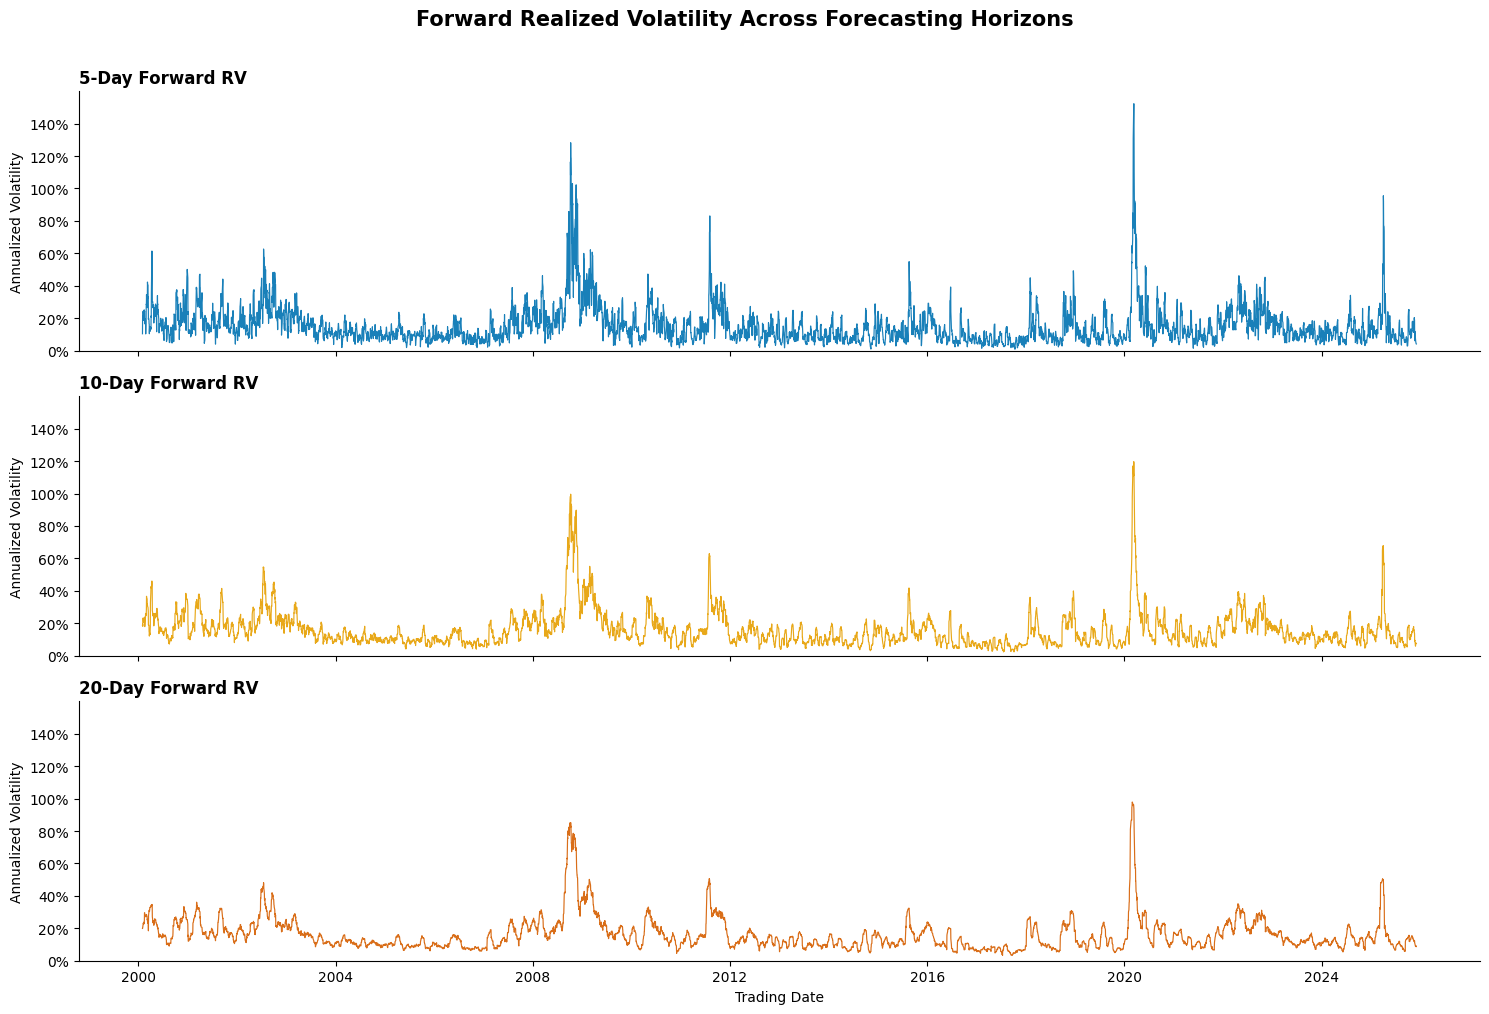

In [14]:
# Forecast horizons and corresponding colors
horizon_config = {
    5: {"color": "#0072B2", "label": "5-Day Forward RV"},
    10: {"color": "#E69F00", "label": "10-Day Forward RV"},
    20: {"color": "#D55E00", "label": "20-Day Forward RV"}
}

# Create and store figure
fig_forward_rv_timeseries, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

# Common vertical scale
y_max = model_a_df[targets].max().max() * 1.05

for ax, (h, config) in zip(axes, horizon_config.items()):
    column = f"Forward_RV_{h}D"

    ax.plot(
        model_a_df["Date"],
        model_a_df[column],
        color=config["color"],
        linewidth=0.85,
        alpha=0.9
    )

    ax.set_title(
        config["label"],
        fontsize=12,
        fontweight="bold",
        loc="left"
    )

    ax.set_ylabel("Annualized Volatility")
    ax.set_ylim(0, y_max)

    ax.yaxis.set_major_formatter(
        mticker.PercentFormatter(xmax=1.0)
    )

    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Trading Date")

fig_forward_rv_timeseries.suptitle(
    "Forward Realized Volatility Across Forecasting Horizons",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

fig_forward_rv_timeseries.tight_layout()
plt.show()

### Observation : Time-Series Analysis

- **Volatility Fluctuations:** The 5-day forward realized volatility target exhibits sharper and more frequent fluctuations, while the 10- and 20-day targets display progressively smoother movements.

- **Volatility Persistence:** Longer forecasting horizons exhibit broader periods of elevated volatility, consistent with the smoothing and overlap introduced by longer return windows.

- **Historical Market Stress:** Major periods of elevated market volatility, particularly around the 2008 global financial crisis and the 2020 COVID-19 market disruption, are visible across all three forecasting horizons, although peak magnitudes differ.

- **Forecasting Implications:** The results highlight the greater sensitivity of the primary 5-day target to short-term volatility shocks. The 10- and 20-day targets provide useful robustness checks for assessing whether the predictive contribution of HMM regime information remains consistent across forecasting horizons.

### 6.4 Distribution Analysis of Forward Realized Volatility

The distributions of the 5-, 10-, and 20-day forward realized volatility targets are examined to assess differences in their concentration, dispersion, and extreme observations.

Kernel density estimates (KDE) are used to compare the overall distribution shapes, while boxplots illustrate differences in the median, interquartile range, and outliers.

This analysis complements the descriptive statistics and time-series visualizations, providing additional insight into the distributional characteristics of the primary 5-day forecasting target and the longer-horizon robustness targets.

Visualization A - Density Distribution

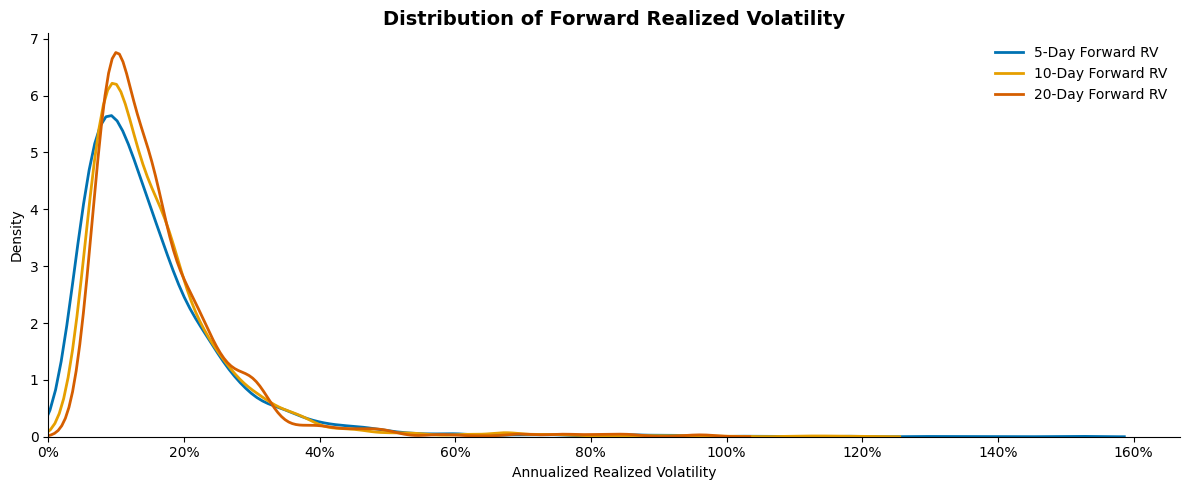

In [15]:
# Consistent horizon color palette
horizon_colors = {
    5: "#0072B2",   # Blue
    10: "#E69F00",  # Orange
    20: "#D55E00"   # Red-orange
}

# Create and store density figure
fig_forward_rv_distribution, ax = plt.subplots(
    figsize=(12, 5)
)

for h in HORIZONS:
    sns.kdeplot(
        data=model_a_df,
        x=f"Forward_RV_{h}D",
        label=f"{h}-Day Forward RV",
        color=horizon_colors[h],
        linewidth=2,
        fill=False,
        ax=ax
    )

ax.set_title(
    "Distribution of Forward Realized Volatility",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Annualized Realized Volatility")
ax.set_ylabel("Density")

ax.set_xlim(left=0)
ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1.0)
)

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

fig_forward_rv_distribution.tight_layout()
plt.show()

Visualization B - Box Plot Comparison

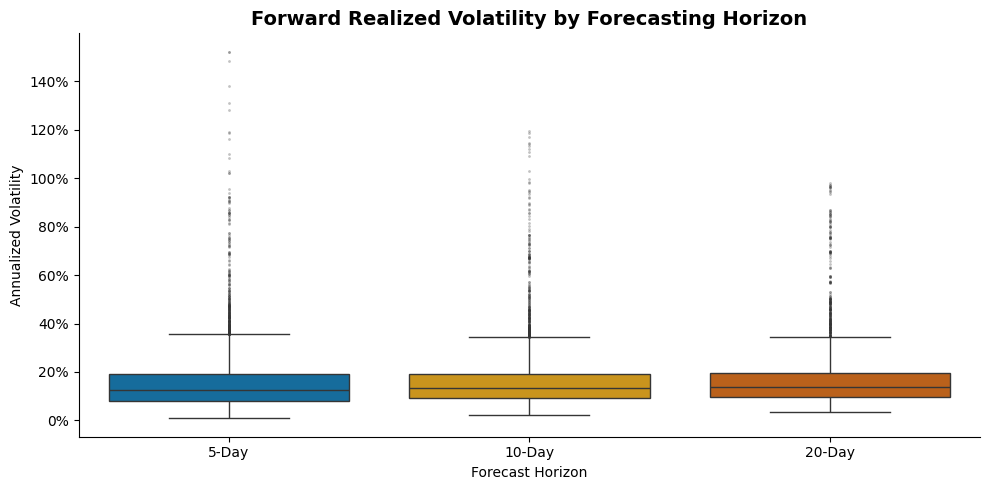

In [16]:

# Reshape targets into long format
rv_long = model_a_df[targets].melt(
    var_name="Forecast Horizon",
    value_name="Annualized Volatility"
)

# Rename horizons for plotting
rv_long["Forecast Horizon"] = (
    rv_long["Forecast Horizon"].replace({
        "Forward_RV_5D": "5-Day",
        "Forward_RV_10D": "10-Day",
        "Forward_RV_20D": "20-Day"
    })
)

horizon_order = ["5-Day", "10-Day", "20-Day"]

# Create and store boxplot figure
fig_forward_rv_boxplot, ax = plt.subplots(
    figsize=(10, 5)
)

sns.boxplot(
    data=rv_long,
    x="Forecast Horizon",
    y="Annualized Volatility",
    order=horizon_order,
    hue="Forecast Horizon",
    hue_order=horizon_order,
    palette={
    "5-Day": "#0072B2",
    "10-Day": "#E69F00",
    "20-Day": "#D55E00"
    },
    dodge=False,
    legend=False,
    showfliers=True,
    flierprops={
        "marker": ".",
        "markersize": 2,
        "alpha": 0.3
    },
    ax=ax
)

ax.set_title(
    "Forward Realized Volatility by Forecasting Horizon",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Annualized Volatility")

ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1.0)
)

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_forward_rv_boxplot.tight_layout()
plt.show()


### Observation : Distribution Analysis

- **Distribution Shape:** All three forward realized volatility targets exhibit right-skewed distributions, with observations concentrated at relatively low volatility levels and extended upper tails.

- **Concentration and Dispersion:** The 20-day target has the highest density peak, indicating greater concentration around typical volatility values. The 5-day target displays a broader distribution, consistent with its higher standard deviation.

- **Extreme Observations:** The boxplots reveal numerous upper-tail outliers across all horizons. The most extreme values occur in the 5-day target, with a maximum annualized volatility of 152.29%, compared with 97.90% for the 20-day target.

- **Forecasting Implications:** The findings suggest that the primary 5-day forecasting target is more sensitive to short-term volatility shocks, while longer horizons produce comparatively smoother target distributions. The subsequent supervised analysis will determine whether these differences influence predictive accuracy and the contribution of HMM regime information.

## 7. Define Market-Only and Regime-Enhanced Predictors

To evaluate the incremental predictive value of the market regime information generated by Model B, two predictor sets are constructed.

The **market-only predictor set** consists of 11 engineered market characteristics, including VIX level and change, historical realized volatility, return skewness, and return kurtosis across 5-, 10-, and 20-day rolling windows.

The **regime-enhanced predictor set** incorporates the same market characteristics alongside the filtered probabilities of the Calm, Transition, and Stressed regimes estimated by Model B's Gaussian Hidden Markov Model.

Both predictor sets are evaluated using identical forecasting horizons and data partitions, allowing us to assess whether incorporating HMM regime information improves predictive performance. The primary analysis focuses on 5-day forward realized volatility, while 10- and 20-day forecasts serve as robustness checks.

### 7.1 Define Predictor Sets

In [17]:

# Market-only predictors
base_features = [
    "VIX_Level",
    "VIX_Change",
    "Realized_Vol_5D",
    "Realized_Vol_10D",
    "Realized_Vol_20D",
    "Return_Skew_5D",
    "Return_Skew_10D",
    "Return_Skew_20D",
    "Return_Kurt_5D",
    "Return_Kurt_10D",
    "Return_Kurt_20D"
]

# Filtered HMM probabilities from Model B
regime_predictors = [
    "Filtered_P_Calm",
    "Filtered_P_Transition",
    "Filtered_P_Stressed"
]

# Regime-enhanced predictor set
enhanced_features = base_features + regime_predictors

# Forecasting targets
HORIZONS = (5, 10, 20)
targets = [f"Forward_RV_{h}D" for h in HORIZONS]

PRIMARY_HORIZON = 5
primary_target = "Forward_RV_5D"

# Validate predictor availability
required_columns = enhanced_features + targets

assert model_a_df[required_columns].notna().all().all(), (
    "Missing values detected in predictors or targets."
)

print("Market-only predictors:", len(base_features))
print("Regime-enhanced predictors:", len(enhanced_features))
print("Primary target:", primary_target)
print("Robustness targets:", targets[1:])


Market-only predictors: 11
Regime-enhanced predictors: 14
Primary target: Forward_RV_5D
Robustness targets: ['Forward_RV_10D', 'Forward_RV_20D']


### 7.2 Predictor Diagnostics : Correlation Analysis

Pearson correlation coefficients are calculated to examine the linear relationships among the market predictors, HMM regime probabilities, and forward realized volatility targets.

The analysis aims to identify potentially redundant predictors and assess whether the regime probabilities exhibit meaningful associations with future volatility across different forecasting horizons.

These relationships are descriptive and do not establish predictive importance or incremental forecasting value, which will be assessed through out-of-sample model evaluation.

Visualization - Predictor Correlation Heatmap

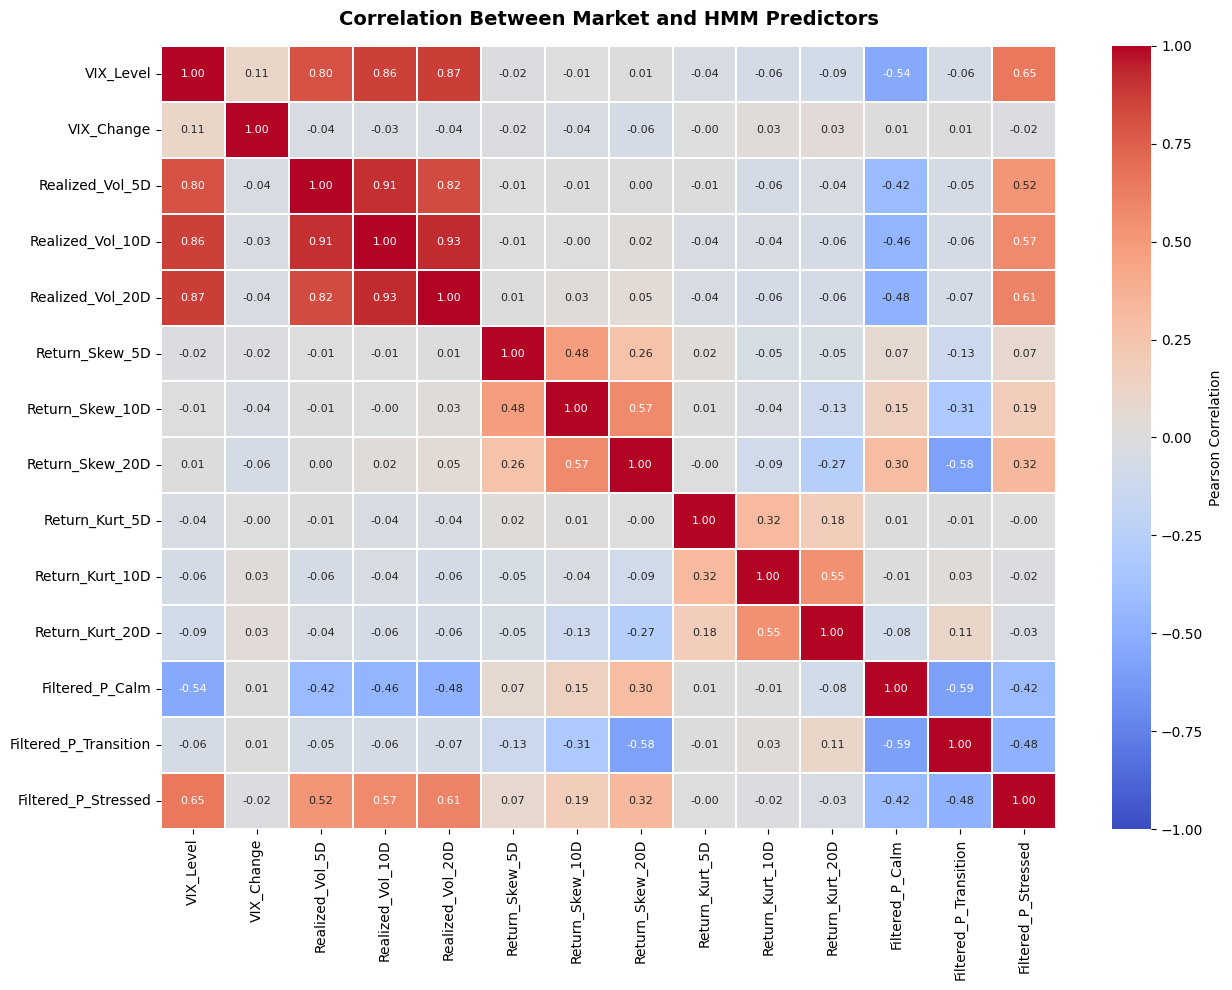

In [18]:

# Calculate predictor correlations
predictor_corr = model_a_df[
    enhanced_features
].corr()

# Create and store figure
fig_predictor_corr, ax = plt.subplots(
    figsize=(13, 10)
)

sns.heatmap(
    predictor_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    annot_kws={"size": 8},
    cbar_kws={"label": "Pearson Correlation"},
    ax=ax
)

ax.set_title(
    "Correlation Between Market and HMM Predictors",
    fontsize=14,
    fontweight="bold",
    pad=15
)

fig_predictor_corr.tight_layout()
plt.show()


Visualization - Predictor Target Correlation Heatmap

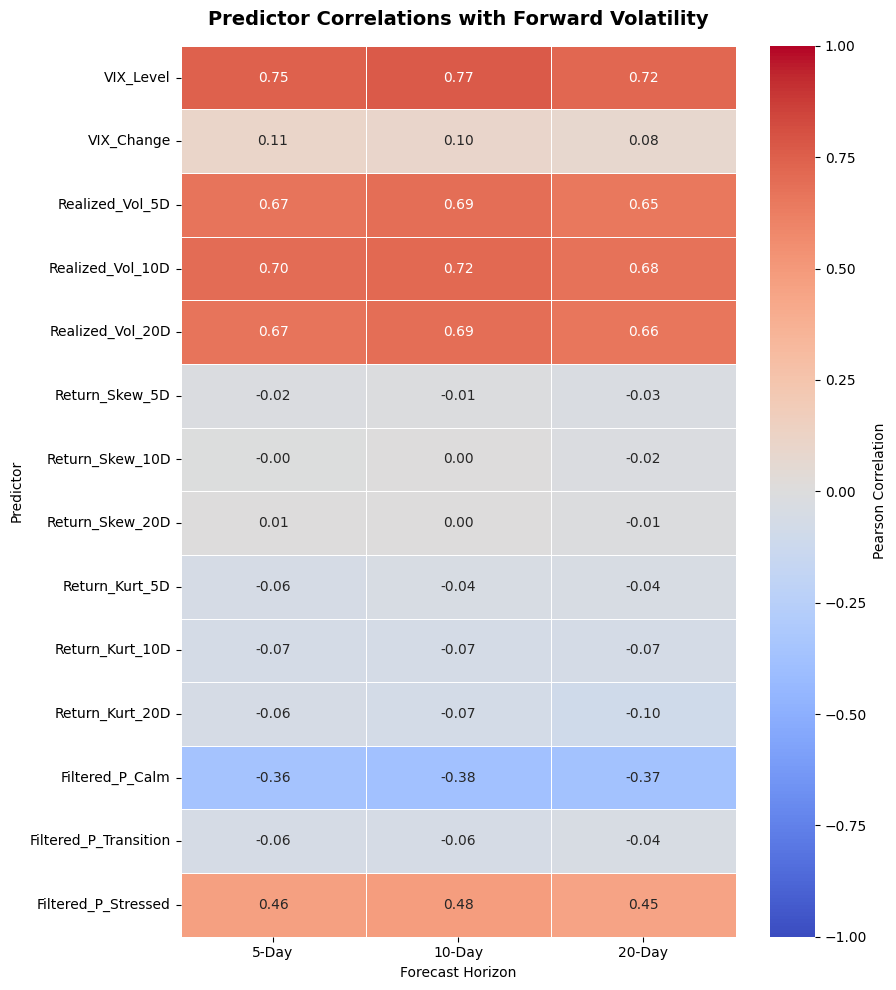

In [19]:

# Calculate correlations between predictors and targets
target_corr = (
    model_a_df[enhanced_features + targets]
    .corr()
    .loc[enhanced_features, targets]
)

# Rename columns for presentation
target_corr.columns = [
    "5-Day",
    "10-Day",
    "20-Day"
]

# Create and store figure
fig_predictor_target_corr, ax = plt.subplots(
    figsize=(9, 10)
)

sns.heatmap(
    target_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"},
    ax=ax
)

ax.set_title(
    "Predictor Correlations with Forward Volatility",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Predictor")

fig_predictor_target_corr.tight_layout()
plt.show()


### Observation : Predictor Correlation Analysis

- **Market Predictor Relationships:** VIX level and historical realized volatility exhibit strong positive correlations, with correlations among the realized volatility measures reaching 0.93. This indicates substantial overlap among volatility-related predictors and supports the use of regularized regression.

- **Regime Characteristics:** The Stressed regime probability is positively correlated with VIX level (0.65), while the Calm regime probability exhibits a negative correlation (−0.54). The Transition regime shows a notable negative relationship with 20-day return skewness (−0.58), suggesting that the inferred regimes capture different aspects of market conditions.

- **Predictor–Target Relationships:** VIX level exhibits the strongest positive correlation with future realized volatility across all forecasting horizons (0.72–0.77), followed by historical realized volatility measures. The Stressed regime probability also demonstrates moderate positive correlations (0.45–0.48), while the Calm regime probability exhibits negative correlations (−0.36 to −0.38).

- **Forecasting Implications:** The HMM regime probabilities contain information associated with future volatility, but their correlation with existing market characteristics suggests potential redundancy. The subsequent supervised analysis will determine whether incorporating regime information improves out-of-sample forecasting accuracy beyond the market-only predictors.

## 8. Chronological Train, Validation, and Test Split

The dataset is divided chronologically into training (2000–2018), validation (2019–2021), and testing (2022–2025) periods to preserve the temporal structure of financial market observations.

The training set is used to estimate the supervised models, the validation set supports model selection and hyperparameter tuning, and the test set provides an independent assessment of forecasting performance.

Because the forward realized volatility targets incorporate returns over the subsequent 5, 10, and 20 trading days, observations near the training and validation boundaries may contain future returns belonging to the next dataset partition. To prevent this overlap, a 20-trading-day boundary purge is applied before each subsequent partition.

The same chronological partitions and boundary exclusions are used across all forecasting horizons to ensure comparability. Feature scaling and model fitting are restricted to the training period to prevent information leakage.

### 8.1 Construct the Chronological Splits

In [20]:

# Sort and validate chronological order
model_a_df = (
    model_a_df.sort_values("Date")
    .reset_index(drop=True)
)

assert model_a_df["Date"].is_monotonic_increasing
assert model_a_df["Date"].is_unique

# Define split boundaries
validation_start = pd.Timestamp("2019-01-01")
test_start = pd.Timestamp("2022-01-01")

# Find first observation in each subsequent period
first_validation_pos = model_a_df["Date"].searchsorted(
    validation_start
)

first_test_pos = model_a_df["Date"].searchsorted(
    test_start
)

# Maximum forecasting horizon
max_h = max(HORIZONS)

# Purge forecast origins near sample boundaries
train_df = model_a_df.iloc[
    :first_validation_pos - max_h
].copy()

validation_df = model_a_df.iloc[
    first_validation_pos:first_test_pos - max_h
].copy()

test_df = model_a_df.iloc[
    first_test_pos:
].copy()

# Validate partitions
assert all(
    len(df) > 0
    for df in [train_df, validation_df, test_df]
)

assert train_df["Date"].max() < validation_df["Date"].min()
assert validation_df["Date"].max() < test_df["Date"].min()

# Summarize partition sizes
split_summary = pd.DataFrame([
    {
        "Dataset": name,
        "Observations": len(df),
        "Start Date": df["Date"].min(),
        "End Date": df["Date"].max()
    }
    for name, df in [
        ("Training", train_df),
        ("Validation", validation_df),
        ("Test", test_df)
    ]
])

display(split_summary)

print("Boundary purge:", max_h, "trading days")
print("Total retained observations:",
      split_summary["Observations"].sum())

print("Observations excluded by boundary purges:",
      len(model_a_df) - split_summary["Observations"].sum())


,Dataset,Observations,Start Date,End Date
0,Training,4739,2000-02-01,2018-11-29
1,Validation,737,2019-01-02,2021-12-02
2,Test,983,2022-01-03,2025-12-02


Boundary purge: 20 trading days
Total retained observations: 6459
Observations excluded by boundary purges: 40


Visualization - Chronological Data Partitions

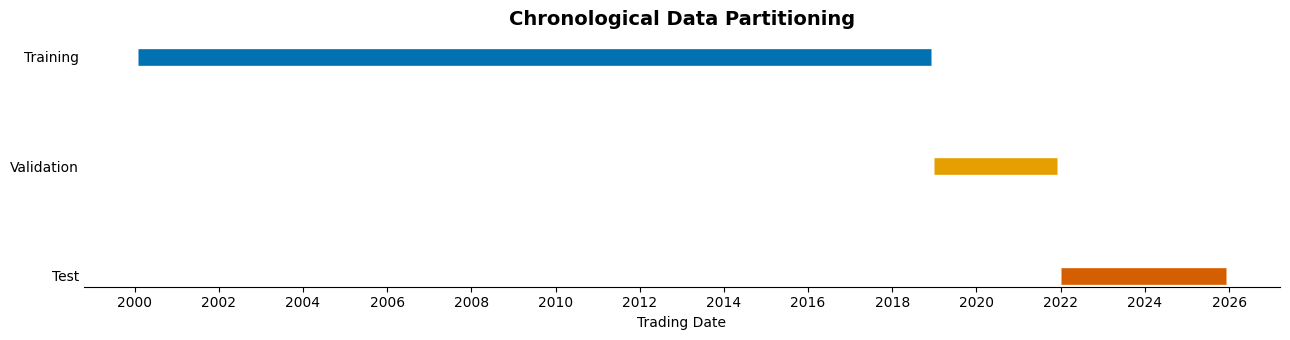

In [21]:
# Color Pallete
split_colors = {
    "Training": "#0072B2",
    "Validation": "#E69F00",
    "Test": "#D55E00"
}

fig_chronological_split, ax = plt.subplots(
    figsize=(13, 3.5)
)

partitions = [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]

for i, (name, df) in enumerate(partitions):
    ax.plot(
        [df["Date"].min(), df["Date"].max()],
        [i, i],
        color=split_colors[name],
        linewidth=12,
        solid_capstyle="butt",
        label=name
    )

ax.set_yticks(range(3))
ax.set_yticklabels(
    ["Training", "Validation", "Test"]
)

ax.invert_yaxis()
ax.set_xlabel("Trading Date")

ax.set_title(
    "Chronological Data Partitioning",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.xaxis.set_major_locator(
    mdates.YearLocator(2)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.grid(False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

fig_chronological_split.tight_layout()
plt.show()

### 8.2 Verify Windows Dont Cross (Validation)

In [22]:

# Verify forward-window boundary protection
# using trading-date positions in the cleaned dataset

train_last_pos = model_a_df.index[
    model_a_df["Date"] == train_df["Date"].max()
][0]

validation_last_pos = model_a_df.index[
    model_a_df["Date"] == validation_df["Date"].max()
][0]

assert train_last_pos + max_h < first_validation_pos
assert validation_last_pos + max_h < first_test_pos

print("Training/validation boundary: PASS")
print("Validation/test boundary: PASS")

print("\nMaximum forecast horizon:",
      max_h, "trading days")


Training/validation boundary: PASS
Validation/test boundary: PASS

Maximum forecast horizon: 20 trading days


### 8.3 Verification of HMM Feature Integrity

The regime probabilities incorporated into Model A were generated by the Gaussian Hidden Markov Model developed in Model B. The HMM and its feature scaler were fitted exclusively on observations from 2000–2017, with subsequent observations reserved for evaluating the learned regime structure.

The economic regime labels were assigned using training-period market characteristics, while filtered probabilities were calculated sequentially using observations available through each trading date. Unlike smoothed posterior probabilities, the filtered probabilities do not condition current regime estimates on future observations.

Consequently, the HMM estimation procedure does not introduce information from Model A's validation (2019–2021) or testing (2022–2025) periods into the regime predictors. Combined with the chronological data partitioning and forward-target boundary purges, this supports a leakage-controlled framework for evaluating the incremental predictive value of market regime information.

### Observations: Chronological Data Partitioning

- **Temporal Separation:** The dataset was partitioned chronologically into training (2000–2018), validation (2019–2021), and testing (2022–2025) periods to preserve the temporal ordering of market observations.

- **Boundary Validation:** Both training-validation and validation-test boundary checks passed, confirming that the 20-trading-day purge prevents forward volatility targets from extending into subsequent data partitions.

- **Forecasting Consistency:** The same partitions and boundary exclusions are applied across the 5-, 10-, and 20-day forecasting horizons, ensuring consistent evaluation samples for the primary analysis and robustness checks.

- **HMM Feature Integrity:** Model B's Gaussian HMM and feature scaler were fitted exclusively on the 2000–2017 training period. Regime labels were assigned using training-period characteristics, while filtered regime probabilities were generated sequentially without conditioning on future observations. This supports the use of HMM regime information in Model A without introducing future validation or test data into HMM parameter estimation.

- **Modeling Implications:** The chronological partitions, boundary purges, and verified HMM estimation procedure establish a leakage-controlled framework for evaluating whether regime information improves out-of-sample volatility forecasting across the three horizons, subject to the underlying market features also being constructed without future information.

## 9. Persistence Baseline : Primary and Robustness Horizons

A persistence baseline is established to evaluate whether supervised learning models can improve volatility forecasting beyond a simple historical benchmark.

The persistence approach assumes that future realized volatility over a given forecasting horizon will equal the realized volatility observed over the preceding period of the same length. Accordingly, trailing 5-, 10-, and 20-day realized volatility are used to predict their corresponding forward volatility targets.

The primary analysis evaluates the 5-day forecasting horizon, while the 10- and 20-day horizons serve as robustness checks.

Forecasting performance is evaluated using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). The resulting baseline establishes a reference for assessing the predictive performance of Ridge Regression and XGBoost, with and without HMM regime information.

### 9.1 Evaluating Persistence Baseline

In [23]:
# Evaluation function
def scores(actual, pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(actual, pred))),
        "MAE": float(mean_absolute_error(actual, pred))
    }

# Store model results and predictions
results_records = []
forecast_records = []

# Evaluate persistence across all horizons
for h in HORIZONS:

    target_col = f"Forward_RV_{h}D"
    baseline_col = f"Realized_Vol_{h}D"

    for sample_name, sample_df in [
        ("Validation", validation_df),
        ("Test", test_df)
    ]:

        actual = sample_df[target_col].to_numpy()
        predicted = sample_df[baseline_col].to_numpy()

        metrics = scores(actual, predicted)

        results_records.append({
            "Model": "Persistence",
            "Features": "Matched trailing volatility",
            "Horizon": h,
            "Sample": sample_name,
            **metrics
        })

        forecast_records.append(pd.DataFrame({
            "Date": sample_df["Date"].to_numpy(),
            "Actual": actual,
            "Predicted": predicted,
            "Model": "Persistence",
            "Features": "Matched trailing volatility",
            "Horizon": h,
            "Sample": sample_name
        }))

# Consolidate results
results = pd.DataFrame(results_records)

forecasts = pd.concat(
    forecast_records,
    ignore_index=True
)

# Display baseline performance
baseline_results = results.sort_values(
    ["Horizon", "Sample"]
)
display(
    baseline_results.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

,Model,Features,Horizon,Sample,RMSE,MAE
1,Persistence,Matched trailing volatility,5,Test,0.0974,0.0647
0,Persistence,Matched trailing volatility,5,Validation,0.1256,0.0794
3,Persistence,Matched trailing volatility,10,Test,0.0849,0.0543
2,Persistence,Matched trailing volatility,10,Validation,0.1312,0.0807
5,Persistence,Matched trailing volatility,20,Test,0.0761,0.0487
4,Persistence,Matched trailing volatility,20,Validation,0.1580,0.0914


### Observation : Interpretation Presestance Forecasting Performance Metrics

Forecasting performance is evaluated using two error metrics:

- **Root Mean Squared Error (RMSE):** Measures the magnitude of forecasting errors, assigning greater weight to larger deviations between predicted and actual volatility. Lower RMSE values indicate better forecasting accuracy, particularly in reducing large prediction errors.

- **Mean Absolute Error (MAE):** Measures the average absolute difference between predicted and actual volatility. Lower MAE values indicate smaller average forecasting errors and provide a more direct interpretation of typical prediction accuracy.

Both metrics are expressed in the same units as the forecasting targets: **annualized realized volatility in decimal form**.

For example, the primary 5-day persistence baseline produces:

- **RMSE = 0.0975:** Equivalent to 9.75 annualized volatility percentage points. This metric emphasizes larger forecasting errors and should not be interpreted as the average absolute error.
- **MAE = 0.0646:** Equivalent to 6.46 annualized volatility percentage points. On average, the persistence forecast differs from actual forward 5-day annualized volatility by 6.46 percentage points.

These values represent absolute forecasting errors in annualized volatility, rather than percentage errors relative to actual volatility. For example, an MAE of 0.0646 does not mean that forecasts are inaccurate by 6.46% in relative terms.

Lower RMSE and MAE indicate better forecasting performance. However, comparisons should be made between models predicting the same forecasting horizon and evaluated over the same sample period.

## 10. Ridge Regression : Market-Only vs. Regime-Enhanced Forecasting

Ridge Regression is implemented as an interpretable, regularized linear forecasting model to evaluate whether historical market characteristics can predict future realized volatility more accurately than the persistence baseline.

Two model specifications are evaluated. The market-only specification uses the 11 engineered market predictors, while the regime-enhanced specification additionally incorporates the filtered probabilities of the Calm, Transition, and Stressed regimes generated by Model B.

Ridge Regression applies L2 regularization to reduce coefficient instability arising from correlated predictors. Predictor variables are standardized using parameters estimated exclusively from the training data.

The regularization parameter is selected using validation period RMSE, and the final models are evaluated on the independent test period. The primary analysis focuses on 5-day forward realized volatility, with 10- and 20-day forecasts serving as robustness checks.

### 10.1 Training and Valitation of Ridge Regression

In [24]:
# Candidate regularization strengths
alpha_grid = [0.01, 0.1, 1, 10, 100, 1000]

ridge_models = {}
ridge_tuning_records = []

feature_sets = {
    "Market-only": base_features,
    "Market + HMM": enhanced_features
}

for h in HORIZONS:
    target_col = f"Forward_RV_{h}D"

    y_train = train_df[target_col]
    y_val = validation_df[target_col]

    for feature_name, feature_cols in feature_sets.items():
        X_train = train_df[feature_cols]
        X_val = validation_df[feature_cols]

        for alpha in alpha_grid:
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("ridge", Ridge(alpha=alpha))
            ])

            pipeline.fit(X_train, y_train)
            val_pred = pipeline.predict(X_val)

            metrics = scores(y_val, val_pred)

            ridge_tuning_records.append({
                "Horizon": h,
                "Features": feature_name,
                "Alpha": alpha,
                "Validation_RMSE": metrics["RMSE"],
                "Validation_MAE": metrics["MAE"]
            })

# Consolidate tuning results
ridge_tuning = pd.DataFrame(ridge_tuning_records)

# Select best alpha for each horizon and feature set
best_ridge = (
    ridge_tuning
    .sort_values(
        ["Validation_RMSE", "Alpha"]
    )
    .groupby(["Horizon", "Features"], as_index=False)
    .first()
    .sort_values(["Horizon", "Features"])
)

display(best_ridge)


,Horizon,Features,Alpha,Validation_RMSE,Validation_MAE
0,5,Market + HMM,0.0100,0.1134,0.0697
1,5,Market-only,10.0000,0.1139,0.0699
2,10,Market + HMM,0.0100,0.1113,0.0672
3,10,Market-only,0.0100,0.1114,0.0672
4,20,Market + HMM,0.0100,0.1249,0.0683
5,20,Market-only,0.0100,0.1245,0.0686


Visualization - Ridge Hyperparameter Selection

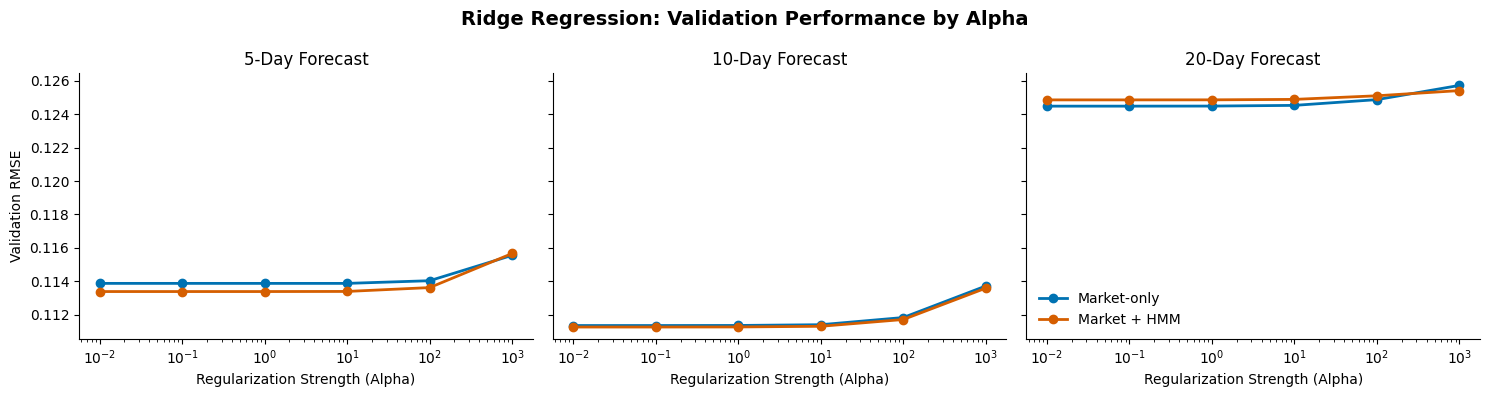

In [25]:

fig_ridge_tuning, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharey=True
)

ridge_colors = {
    "Market-only": "#0072B2",
    "Market + HMM": "#D55E00"
}

for ax, h in zip(axes, HORIZONS):
    subset = ridge_tuning[
        ridge_tuning["Horizon"] == h
    ]

    for feature_name in feature_sets:
        data = subset[
            subset["Features"] == feature_name
        ].sort_values("Alpha")

        ax.plot(
            data["Alpha"],
            data["Validation_RMSE"],
            marker="o",
            linewidth=2,
            color=ridge_colors[feature_name],
            label=feature_name
        )

    ax.set_xscale("log")
    ax.set_title(f"{h}-Day Forecast")
    ax.set_xlabel("Regularization Strength (Alpha)")
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Validation RMSE")
axes[-1].legend(frameon=False)

fig_ridge_tuning.suptitle(
    "Ridge Regression: Validation Performance by Alpha",
    fontsize=14,
    fontweight="bold"
)

fig_ridge_tuning.tight_layout()
plt.show()


### Observation : Ridge Regression Hyperparameter Selection

- **Primary Forecasting Horizon:** The regime-enhanced Ridge model achieved a validation RMSE of 0.1134, compared with 0.1139 for the market-only model, representing a modest improvement of approximately 0.44%.

- **Horizon Sensitivity:** Incorporating HMM regime probabilities produced a marginal improvement at the 10-day horizon, while the market-only model achieved slightly lower RMSE at the 20-day horizon. This suggests that the incremental predictive contribution of regime information varies across forecasting horizons.

- **Regularization Sensitivity:** Validation RMSE remained relatively stable across most candidate regularization strengths. The selected alpha was 0.01 for five of the six configurations, while the 5-day market-only model selected alpha = 10.

- **Baseline Comparison:** Ridge Regression improved validation RMSE relative to the persistence baseline across all three horizons, with approximate improvements ranging from 9.7% to 21.2%. These findings provide preliminary evidence that market characteristics offer predictive value beyond historical volatility persistence.

- **Modeling Implications:** Although the regime-enhanced specification shows a small improvement at the primary forecasting horizon, its incremental value remains uncertain. Final conclusions will depend on performance in the independent test period.

### 10.2 Final Ridge Regression Evaluation

Following validation based hyperparameter selection, the six Ridge Regression configurations are evaluated on the independent 2022–2025 test dataset.

For each forecasting horizon, the market-only and regime-enhanced models are fitted using the training observations and their previously selected regularization parameters. Predictor standardization is estimated exclusively from the training data.

Out-of-sample performance is assessed using RMSE and MAE, with additional comparisons against the persistence baseline. The evaluation focuses primarily on the 5-day forecasting horizon, while the 10- and 20-day results assess robustness across longer forecasting periods.

This analysis determines whether incorporating HMM regime probabilities provides incremental forecasting improvements beyond the original market predictors.

In [26]:
# NOTE: run this cell once, re-running it without resetting would cause duplicate entries for "results" & "forecasts" df's
# Fit selected Ridge models and evaluate test performance

ridge_models = {}
ridge_result_records = []
ridge_forecast_records = []

for _, config in best_ridge.iterrows():

    h = int(config["Horizon"])
    feature_name = config["Features"]
    alpha = float(config["Alpha"])

    feature_cols = feature_sets[feature_name]
    target_col = f"Forward_RV_{h}D"

    # Training observations
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    # Test observations
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # Build and fit the selected pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    pipeline.fit(X_train, y_train)

    # Generate out-of-sample forecasts
    test_pred = pipeline.predict(X_test)

    # Calculate test performance
    metrics = scores(y_test, test_pred)

    ridge_models[(h, feature_name)] = pipeline

    ridge_result_records.append({
        "Model": "Ridge",
        "Features": feature_name,
        "Horizon": h,
        "Sample": "Test",
        **metrics
    })

    ridge_forecast_records.append(pd.DataFrame({
        "Date": test_df["Date"].to_numpy(),
        "Actual": y_test.to_numpy(),
        "Predicted": test_pred,
        "Model": "Ridge",
        "Features": feature_name,
        "Horizon": h,
        "Sample": "Test"
    }))

# Append Ridge results to the existing persistence results
results = pd.concat([
    results,
    pd.DataFrame(ridge_result_records)
], ignore_index=True)

forecasts = pd.concat([
    forecasts,
    *ridge_forecast_records
], ignore_index=True)

# Display test results
ridge_test_results = (
    results[
        (results["Model"] == "Ridge") &
        (results["Sample"] == "Test")
    ]
    .sort_values(["Horizon", "Features"])
)

display(
    ridge_test_results.style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)


,Model,Features,Horizon,Sample,RMSE,MAE
6,Ridge,Market + HMM,5,Test,0.0740,0.0494
7,Ridge,Market-only,5,Test,0.0738,0.0492
8,Ridge,Market + HMM,10,Test,0.0673,0.0428
9,Ridge,Market-only,10,Test,0.0670,0.0427
10,Ridge,Market + HMM,20,Test,0.0611,0.0393
11,Ridge,Market-only,20,Test,0.0607,0.0392


### 10.3 Copare Ridge Regression Against Persistence

In [27]:

# Select test-period results
test_results = results[
    results["Sample"] == "Test"
].copy()

# Retrieve persistence benchmark by horizon
baseline = (
    test_results[test_results["Model"] == "Persistence"]
    .set_index("Horizon")[["RMSE", "MAE"]]
)

# Select Ridge results
ridge_comparison = test_results[
    test_results["Model"] == "Ridge"
].copy()

# Calculate percentage improvements
for metric in ["RMSE", "MAE"]:
    ridge_comparison[f"{metric}_Improvement_%"] = (
        1 - ridge_comparison[metric] /
        ridge_comparison["Horizon"].map(baseline[metric])
    ) * 100

display(
    ridge_comparison[
        ["Horizon", "Features", "RMSE", "MAE",
         "RMSE_Improvement_%", "MAE_Improvement_%"]
    ].sort_values(["Horizon", "Features"]).style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "RMSE_Improvement_%": "{:+.2f}%",
        "MAE_Improvement_%": "{:+.2f}%"
    })
)


,Horizon,Features,RMSE,MAE,RMSE_Improvement_%,MAE_Improvement_%
6,5,Market + HMM,0.0740,0.0494,+24.05%,+23.62%
7,5,Market-only,0.0738,0.0492,+24.23%,+24.01%
8,10,Market + HMM,0.0673,0.0428,+20.67%,+21.07%
9,10,Market-only,0.0670,0.0427,+21.11%,+21.28%
10,20,Market + HMM,0.0611,0.0393,+19.69%,+19.32%
11,20,Market-only,0.0607,0.0392,+20.22%,+19.65%


Visualization - Actual vs. Predicted 5-Day Volatility

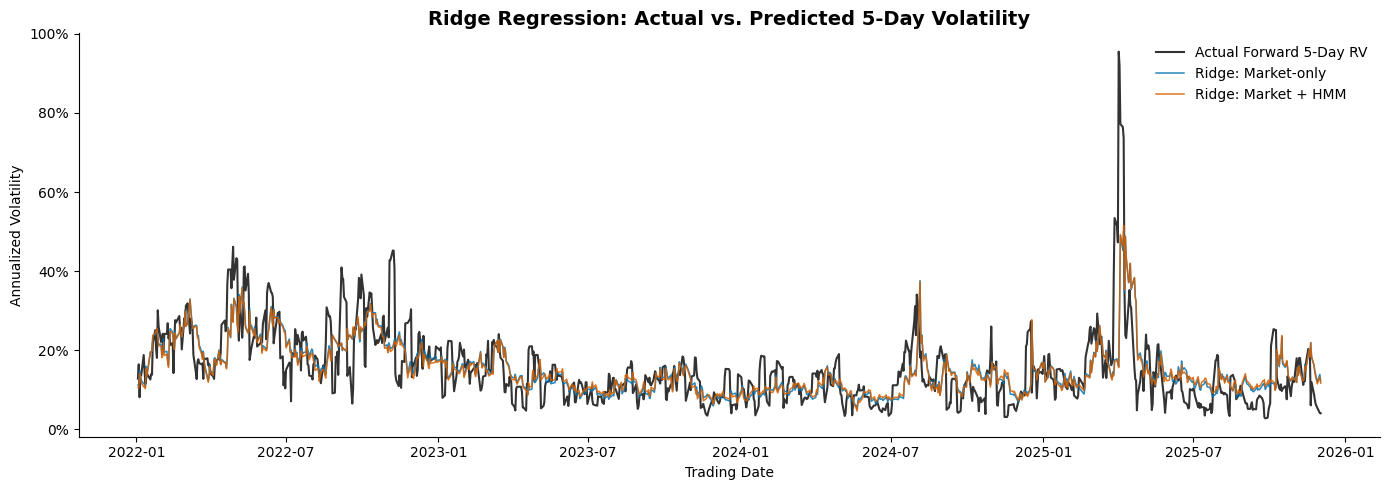

In [28]:

# Primary 5-day Ridge predictions
ridge_plot = forecasts[
    (forecasts["Model"] == "Ridge") &
    (forecasts["Horizon"] == 5) &
    (forecasts["Sample"] == "Test")
]

ridge_wide = ridge_plot.pivot(
    index="Date",
    columns="Features",
    values="Predicted"
).sort_index()

actual_5d = test_df.set_index("Date")[
    "Forward_RV_5D"
].reindex(ridge_wide.index)

# Create and store figure
fig_ridge_5d_predictions, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    actual_5d.index,
    actual_5d,
    label="Actual Forward 5-Day RV",
    color="#333333",
    linewidth=1.5
)

ax.plot(
    ridge_wide.index,
    ridge_wide["Market-only"],
    label="Ridge: Market-only",
    color="#0072B2",
    linewidth=1.1,
    alpha=0.85
)

ax.plot(
    ridge_wide.index,
    ridge_wide["Market + HMM"],
    label="Ridge: Market + HMM",
    color="#D55E00",
    linewidth=1.1,
    alpha=0.85
)

ax.set_title(
    "Ridge Regression: Actual vs. Predicted 5-Day Volatility",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Trading Date")
ax.set_ylabel("Annualized Volatility")
ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1.0)
)

ax.legend(frameon=False)
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_ridge_5d_predictions.tight_layout()
plt.show()


Visualization - Incremental Contribution of HMM Information

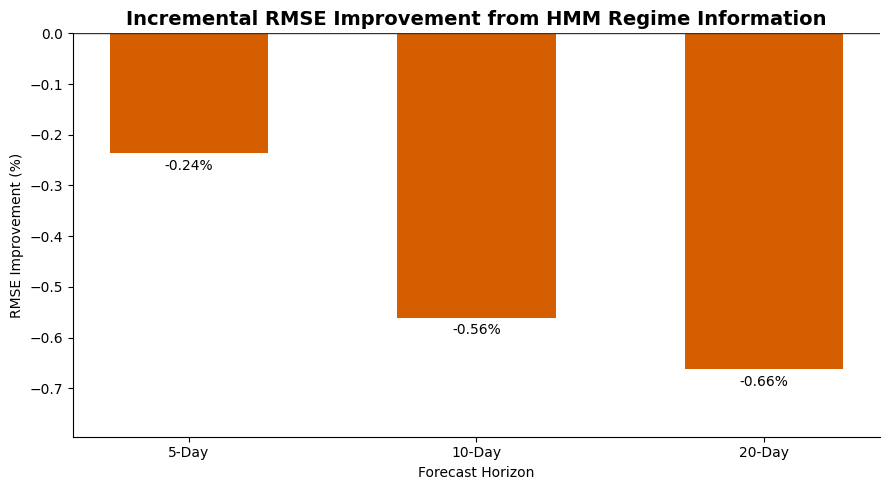

In [29]:

# Compare market-only against regime-enhanced Ridge
ridge_rmse = ridge_test_results.pivot(
    index="Horizon",
    columns="Features",
    values="RMSE"
)

hmm_improvement = (
    1 - ridge_rmse["Market + HMM"] /
    ridge_rmse["Market-only"]
) * 100

fig_ridge_hmm_improvement, ax = plt.subplots(
    figsize=(9, 5)
)

bar_colors = [
    "#0072B2" if value >= 0 else "#D55E00"
    for value in hmm_improvement
]

bars = ax.bar(
    [f"{h}-Day" for h in hmm_improvement.index],
    hmm_improvement.values,
    color=bar_colors,
    width=0.55
)

ax.axhline(0, color="#333333", linewidth=1)

ax.bar_label(
    bars,
    fmt="%+.2f%%",
    padding=4
)

ax.set_title(
    "Incremental RMSE Improvement from HMM Regime Information",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("RMSE Improvement (%)")

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.2)

fig_ridge_hmm_improvement.tight_layout()
plt.show()

Visualization - Actual Vs. Predicted 5-Day Volatility

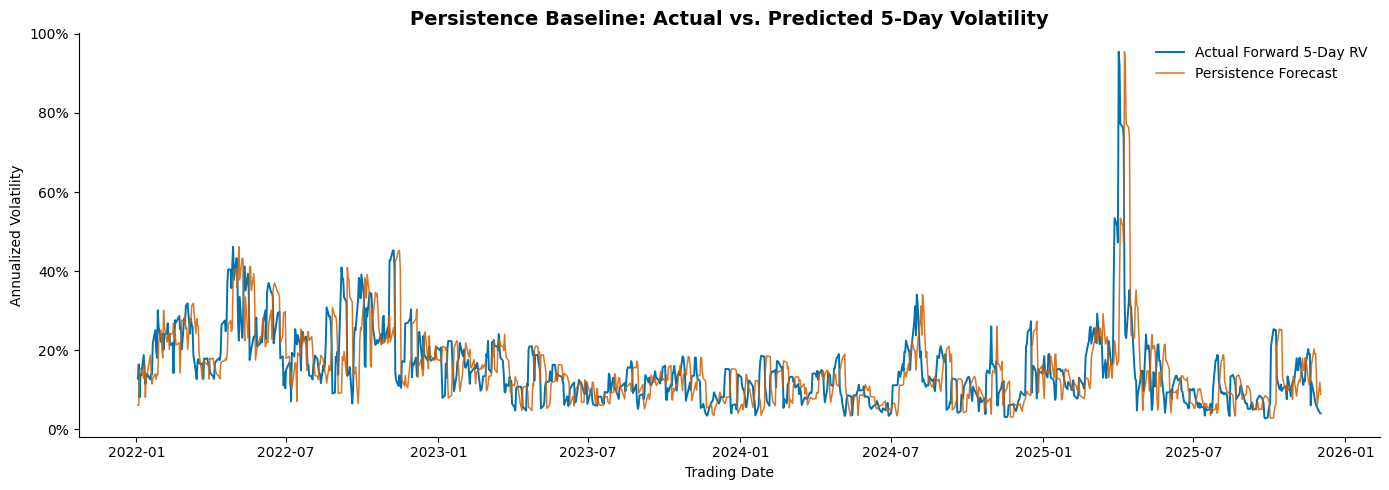

In [68]:
# Actual vs. Predicted 5-Day Volatility
baseline_5d = forecasts[
    (forecasts["Model"] == "Persistence") &
    (forecasts["Horizon"] == 5) &
    (forecasts["Sample"] == "Test")
].sort_values("Date")

fig_persistence_5d, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    baseline_5d["Date"],
    baseline_5d["Actual"],
    label="Actual Forward 5-Day RV",
    color="#0072B2",
    linewidth=1.4
)

ax.plot(
    baseline_5d["Date"],
    baseline_5d["Predicted"],
    label="Persistence Forecast",
    color="#D55E00",
    linewidth=1.1,
    alpha=0.85
)

ax.set_title(
    "Persistence Baseline: Actual vs. Predicted 5-Day Volatility",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Trading Date")
ax.set_ylabel("Annualized Volatility")
ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1.0)
)
ax.legend(frameon=False)
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_persistence_5d.tight_layout()
plt.show()


Visualization - Test Period Forecast Errors

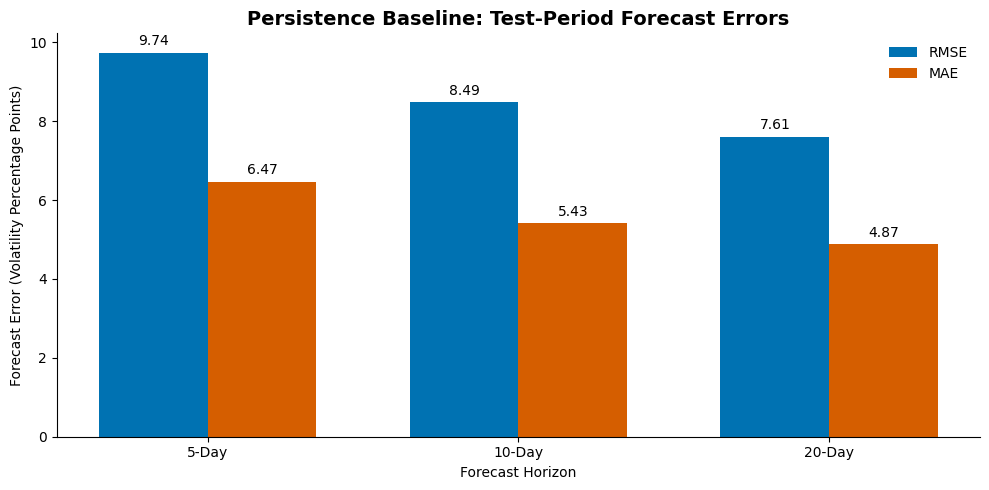

In [69]:
#  Test-Period Forecast Errors
baseline_test = results[
    (results["Model"] == "Persistence") &
    (results["Sample"] == "Test")
].sort_values("Horizon")

x = np.arange(len(baseline_test))
width = 0.35

fig_persistence_errors, ax = plt.subplots(
    figsize=(10, 5)
)

bars_rmse = ax.bar(
    x - width / 2,
    baseline_test["RMSE"] * 100,
    width,
    label="RMSE",
    color="#0072B2"
)

bars_mae = ax.bar(
    x + width / 2,
    baseline_test["MAE"] * 100,
    width,
    label="MAE",
    color="#D55E00"
)

ax.bar_label(bars_rmse, fmt="%.2f", padding=3)
ax.bar_label(bars_mae, fmt="%.2f", padding=3)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{h}-Day" for h in baseline_test["Horizon"]]
)

ax.set_title(
    "Persistence Baseline: Test-Period Forecast Errors",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Forecast Error (Volatility Percentage Points)")
ax.legend(frameon=False)
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_persistence_errors.tight_layout()
plt.show()


### Observation : Ridge Regression Test Performance

- **Primary Forecasting Performance:** The market-only Ridge model achieved a test RMSE of 0.0738 and MAE of 0.0490 for the 5-day forecast, improving upon the persistence baseline by 24.30% and 24.18%, respectively.

- **Incremental HMM Contribution:** Adding HMM regime probabilities resulted in marginal RMSE deterioration of 0.28%, 0.61%, and 0.70% for the 5-, 10-, and 20-day forecasts, respectively. This suggests that regime information provides limited incremental predictive value within the Ridge Regression specification.

- **Volatility Tracking:** Both Ridge models generally captured broad changes in realized volatility but underestimated extreme volatility spikes, particularly during the sharp market disruption observed in 2025.

- **Horizon Robustness:** Ridge Regression consistently outperformed the persistence baseline across all three horizons, with market-only RMSE improvements ranging from 20.27% to 24.30%. However, the additional HMM predictors did not improve forecasting accuracy at any horizon.

- **Modeling Implications:** Historical market characteristics offer substantial predictive improvements over persistence, while the inclusion of HMM regime probabilities provides no additional benefit within the tested linear specification. The subsequent XGBoost analysis will investigate whether nonlinear relationships and interactions can extract further predictive value from regime information.

## 11. XGBoost Regression : Market-Only vs. Regime-Enhanced Forecasting

XGBoost Regression is implemented as a nonlinear supervised learning approach to investigate whether complex relationships and interactions among market characteristics and HMM regime probabilities improve forward realized volatility forecasting.

Two model specifications are evaluated: a **market-only model** using the 11 engineered market predictors and a **regime-enhanced model** incorporating the three filtered HMM probabilities generated by Model B.

Unlike Ridge Regression, XGBoost uses an ensemble of sequentially boosted decision trees to capture nonlinear relationships and feature interactions. This allows us to investigate whether the inferred market regimes provide predictive information that may not be captured by a regularized linear model.

To balance model complexity and predictive performance, a **controlled hyperparameter search** is conducted across the number of boosting trees, maximum tree depth, and learning rate. Row and feature subsampling rates are held constant. Candidate configurations are fitted on the training dataset and evaluated using validation RMSE, with the best-performing configuration selected separately for each forecasting horizon and predictor set.

The selected models are subsequently evaluated on the independent test dataset using RMSE and MAE. The primary analysis focuses on **5-day forward realized volatility**, while 10- and 20-day forecasts serve as robustness checks.

Finally, XGBoost performance is compared against the persistence baseline and Ridge Regression to determine whether nonlinear modeling improves forecasting accuracy and whether HMM regime information provides additional predictive value across forecasting horizons.

### 11.1 Hyperparameter Exploration Framework

To identify suitable XGBoost configurations, a controlled hyperparameter search is performed to examine how ensemble size, tree complexity, and learning rate influence volatility forecasting performance.

The following parameters are explored:

| Hyperparameter | Values Explored | Purpose |
|---|---|---|
| **Number of Trees (`n_estimators`)** | 150, 250, 400 | Examines whether increasing the number of boosting trees improves forecasting accuracy. |
| **Maximum Tree Depth (`max_depth`)** | 2, 3, 4 | Evaluates how tree complexity and the ability to capture nonlinear feature interactions affect performance. |
| **Learning Rate (`learning_rate`)** | 0.03, 0.05 | Examines whether smaller boosting updates improve generalization. |
| **Row Subsampling (`subsample`)** | 0.85 (fixed) | Uses 85% of training observations per boosting iteration to help control overfitting. |
| **Feature Subsampling (`colsample_bytree`)** | 0.90 (fixed) | Samples 90% of predictors per tree to reduce dependence on individual features. |

The search evaluates **18 hyperparameter combinations** for each predictor specification and forecasting horizon, resulting in **108 model configurations** across the three horizons and two predictor sets.

Each configuration is trained using the training dataset and evaluated using validation RMSE. The configuration with the lowest validation RMSE is selected for each forecasting horizon and predictor set, with simpler configurations preferred in the event of a tie.

The selected models are subsequently evaluated on the independent test dataset to assess forecasting accuracy and the incremental contribution of HMM regime information.

### 11.2 XGBoost Hyperparameter Search Implementation
A grid search is performed across the predefined hyperparameter combinations for both the market-only and regime-enhanced XGBoost specifications.

Each configuration is fitted using training-period observations and evaluated against the validation dataset using RMSE and MAE. The search is repeated for the primary 5-day forecasting horizon and the 10- and 20-day robustness horizons.

The results are stored for subsequent hyperparameter selection and sensitivity analysis. The independent test dataset remains excluded from this procedure.

In [30]:
# Define hyperparameter search space
xgb_param_grid = {
    "n_estimators": [150, 250, 400],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.03, 0.05]
}

# Define predictor specifications
xgb_feature_sets = {
    "Market-only": base_features,
    "Market + HMM": enhanced_features
}

# Initialize results storage
xgb_tuning_records = []

# Evaluate candidate configurations
for h in HORIZONS:

    target_col = f"Forward_RV_{h}D"

    for feature_name, feature_cols in xgb_feature_sets.items():

        X_train = train_df[feature_cols]
        y_train = train_df[target_col]

        X_val = validation_df[feature_cols]
        y_val = validation_df[target_col]

        for n_estimators, max_depth, learning_rate in product(
            xgb_param_grid["n_estimators"],
            xgb_param_grid["max_depth"],
            xgb_param_grid["learning_rate"]
        ):

            model = XGBRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                subsample=0.85,
                colsample_bytree=0.90,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=2
            )

            model.fit(X_train, y_train)

            val_pred = model.predict(X_val)
            metrics = scores(y_val, val_pred)

            xgb_tuning_records.append({
                "Horizon": h,
                "Features": feature_name,
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "learning_rate": learning_rate,
                "Validation_RMSE": metrics["RMSE"],
                "Validation_MAE": metrics["MAE"]
            })

# Consolidate results
xgb_tuning = pd.DataFrame(xgb_tuning_records)

print("Total configurations evaluated:", len(xgb_tuning))
print("\nConfigurations by horizon and predictor set:")

display(
    xgb_tuning.groupby(
        ["Horizon", "Features"]
    ).size().rename("Configurations")
)

display(xgb_tuning.head())

Total configurations evaluated: 108

Configurations by horizon and predictor set:


Horizon  Features    
5        Market + HMM    18
         Market-only     18
10       Market + HMM    18
         Market-only     18
20       Market + HMM    18
         Market-only     18
Name: Configurations, dtype: int64

,Horizon,Features,n_estimators,max_depth,learning_rate,Validation_RMSE,Validation_MAE
0,5,Market-only,150,2,0.0300,0.1122,0.0702
1,5,Market-only,150,2,0.0500,0.1115,0.0709
2,5,Market-only,150,3,0.0300,0.1149,0.0733
3,5,Market-only,150,3,0.0500,0.1159,0.0745
4,5,Market-only,150,4,0.0300,0.1182,0.0755


### 11.3 Optimal Hyperparameter Selection

Following the hyperparameter search, the configuration achieving the lowest validation RMSE is selected separately for each forecasting horizon and predictor specification.

This procedure identifies the preferred combination of boosting trees, maximum tree depth, and learning rate within the predefined search space.

The selected configurations are subsequently examined to determine whether model complexity and preferred hyperparameters differ between the market-only and regime-enhanced specifications. Final forecasting performance will be assessed using the independent test dataset.

In [31]:

# Select configuration with lowest validation RMSE
best_xgb = (
    xgb_tuning
    .sort_values([
        "Validation_RMSE",
        "max_depth",
        "n_estimators",
        "learning_rate"
    ])
    .groupby(
        ["Horizon", "Features"],
        as_index=False
    )
    .first()
    .sort_values(["Horizon", "Features"])
    .reset_index(drop=True)
)

# Display selected configurations
display(
    best_xgb.style.format({
        "learning_rate": "{:.2f}",
        "Validation_RMSE": "{:.4f}",
        "Validation_MAE": "{:.4f}"
    })
)


,Horizon,Features,n_estimators,max_depth,learning_rate,Validation_RMSE,Validation_MAE
0,5,Market + HMM,150,2,0.05,0.1108,0.0703
1,5,Market-only,150,2,0.05,0.1115,0.0709
2,10,Market + HMM,400,2,0.03,0.1097,0.0674
3,10,Market-only,150,2,0.05,0.1093,0.0671
4,20,Market + HMM,400,2,0.05,0.1241,0.0684
5,20,Market-only,400,2,0.03,0.1248,0.0683


Visualization - XGBoost Hyperparameter Sensitivity Visualization

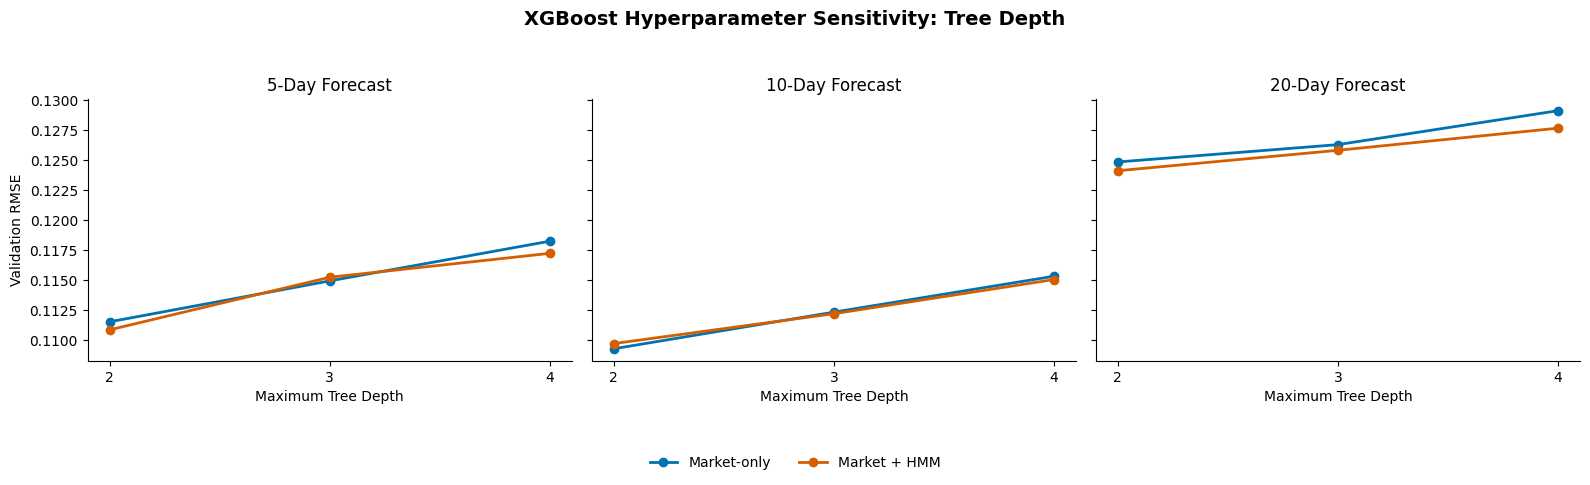

In [32]:

# color palette
model_colors = {
    "Market-only": "#0072B2",
    "Market + HMM": "#D55E00"
}

# Create and store figure
fig_xgb_tuning, axes = plt.subplots(
    1, 3,
    figsize=(16, 4.5),
    sharey=True
)

for ax, h in zip(axes, HORIZONS):

    subset = xgb_tuning[
        xgb_tuning["Horizon"] == h
    ]

    # Minimum validation RMSE at each depth
    plot_data = (
        subset.groupby(
            ["max_depth", "Features"],
            as_index=False
        )["Validation_RMSE"]
        .min()
    )

    for feature_name, color in model_colors.items():

        data = plot_data[
            plot_data["Features"] == feature_name
        ].sort_values("max_depth")

        ax.plot(
            data["max_depth"],
            data["Validation_RMSE"],
            color=color,
            marker="o",
            linewidth=2,
            label=feature_name
        )

    ax.set_title(f"{h}-Day Forecast")
    ax.set_xlabel("Maximum Tree Depth")
    ax.set_xticks([2, 3, 4])
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Validation RMSE")

handles, labels = axes[0].get_legend_handles_labels()

fig_xgb_tuning.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=2,
    frameon=False
)

fig_xgb_tuning.suptitle(
    "XGBoost Hyperparameter Sensitivity: Tree Depth",
    fontsize=14,
    fontweight="bold"
)

fig_xgb_tuning.tight_layout(rect=[0, 0.07, 1, 0.94])
plt.show()



Visualization - Incremental RMSE Improvement from HMM Regime Information (Validation)

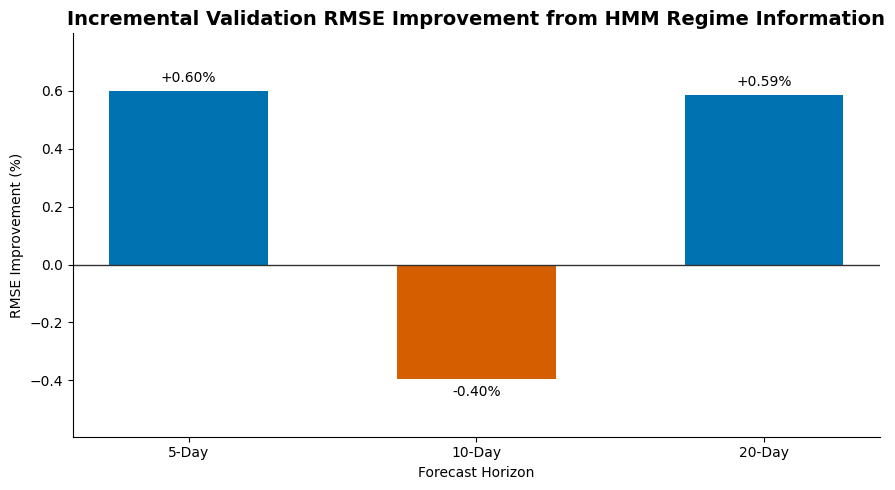

In [33]:
# Pivot validation RMSE results
xgb_rmse_compare = best_xgb.pivot(
    index="Horizon",
    columns="Features",
    values="Validation_RMSE"
)

# Calculate incremental improvement from adding HMM
xgb_hmm_improvement = (
    1 - xgb_rmse_compare["Market + HMM"] /
    xgb_rmse_compare["Market-only"]
) * 100

# Create and store figure
fig_xgb_hmm_improvement, ax = plt.subplots(
    figsize=(9, 5)
)

# Blue if HMM helped, red-orange if it worsened performance
bar_colors = [
    "#0072B2" if value >= 0 else "#D55E00"
    for value in xgb_hmm_improvement
]

bars = ax.bar(
    [f"{h}-Day" for h in xgb_hmm_improvement.index],
    xgb_hmm_improvement.values,
    color=bar_colors,
    width=0.55
)

ax.axhline(0, color="#333333", linewidth=1)

ax.bar_label(
    bars,
    fmt="%+.2f%%",
    padding=4
)

ax.set_title(
    "Incremental Validation RMSE Improvement from HMM Regime Information",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("RMSE Improvement (%)")

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.2)

fig_xgb_hmm_improvement.tight_layout()
plt.show()

### Observation : Incremental HMM Contribution to XGBoots Performance

- **Primary Forecasting Horizon:** Incorporating HMM regime probabilities reduced XGBoost validation RMSE by 0.60% for the 5-day forecast, indicating a modest improvement over the market-only specification.

- **Horizon Sensitivity:** The contribution of regime information varied across forecasting horizons, with a 0.40% deterioration at the 10-day horizon and a 0.59% improvement at the 20-day horizon.

- **Predictive Contribution:** Although XGBoost allows for nonlinear relationships and feature interactions, the incremental improvements from incorporating HMM probabilities remained below 1% across all horizons. This suggests that the additional regime information provides limited benefits during validation.

- **Modeling Implications:** The mixed results indicate that the predictive contribution of HMM regime information is not consistent across forecasting horizons. Independent test-period evaluation is required to determine whether these modest improvements generalize beyond the validation sample.

### 11.4 Final XGBoost Test Evaluation

Following validation-based hyperparameter selection, the six preferred XGBoost configurations are evaluated on the independent 2022–2025 test dataset.

Each configuration is fitted using the original training observations and its selected hyperparameters, without incorporating validation or test observations into model estimation. Forecasts are generated for the three horizons using the market-only and regime-enhanced predictor sets.

Out of sample forecasting performance is evaluated using RMSE and MAE. Results are compared against the persistence baseline and Ridge Regression to assess the benefits of nonlinear modeling.

Particular attention is given to the incremental RMSE improvement from incorporating HMM regime probabilities, determining whether the modest validation improvements translate into better independent test performance.

We'll evaluate three comparisons:
1. XGBoost vs. persistence: Does nonlinear modeling improve upon historical volatility persistence?
2. XGBoost vs. Ridge Regression: Does nonlinear modeling outperform our regularized linear benchmark?
3. Market-only vs. Market + HMM: Does regime information provide incremental predictive value?

### 11.4 Fit Selected XGBoost Models and Evaluate Test Preformance

In [34]:

# Fit selected XGBoost models and evaluate test performance

xgb_models = {}
xgb_result_records = []
xgb_forecast_records = []

for _, config in best_xgb.iterrows():

    h = int(config["Horizon"])
    feature_name = config["Features"]

    feature_cols = xgb_feature_sets[feature_name]
    target_col = f"Forward_RV_{h}D"

    # Selected hyperparameters
    params = {
        "n_estimators": int(config["n_estimators"]),
        "max_depth": int(config["max_depth"]),
        "learning_rate": float(config["learning_rate"]),
        "subsample": 0.85,
        "colsample_bytree": 0.90,
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": 2
    }

    # Training observations
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    # Independent test observations
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    # Fit selected XGBoost configuration
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    # Generate test predictions
    test_pred = model.predict(X_test)

    # Calculate forecasting errors
    metrics = scores(y_test, test_pred)

    # Store fitted model
    xgb_models[(h, feature_name)] = model

    # Store test performance
    xgb_result_records.append({
        "Model": "XGBoost",
        "Features": feature_name,
        "Horizon": h,
        "Sample": "Test",
        **metrics
    })

    # Store individual forecasts
    xgb_forecast_records.append(pd.DataFrame({
        "Date": test_df["Date"].to_numpy(),
        "Actual": y_test.to_numpy(),
        "Predicted": test_pred,
        "Model": "XGBoost",
        "Features": feature_name,
        "Horizon": h,
        "Sample": "Test"
    }))

# Consolidate XGBoost results
xgb_test_results = pd.DataFrame(xgb_result_records)

xgb_test_forecasts = pd.concat(
    xgb_forecast_records,
    ignore_index=True
)

# Replace existing XGBoost entries if cell is rerun
results = pd.concat([
    results[results["Model"] != "XGBoost"],
    xgb_test_results
], ignore_index=True)

forecasts = pd.concat([
    forecasts[forecasts["Model"] != "XGBoost"],
    xgb_test_forecasts
], ignore_index=True)

# Display XGBoost test performance
display(
    xgb_test_results
    .sort_values(["Horizon", "Features"])
    .style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

,Model,Features,Horizon,Sample,RMSE,MAE
0,XGBoost,Market + HMM,5,Test,0.0769,0.0504
1,XGBoost,Market-only,5,Test,0.0756,0.0497
2,XGBoost,Market + HMM,10,Test,0.0711,0.0430
3,XGBoost,Market-only,10,Test,0.0698,0.0427
4,XGBoost,Market + HMM,20,Test,0.0646,0.0396
5,XGBoost,Market-only,20,Test,0.0631,0.0388


### 11.4 Compare XGBoost with Persistence and Ridge Regression

In [35]:

# Extract independent test results
test_results = results[
    results["Sample"] == "Test"
].copy()

# Prepare benchmark RMSE values
persistence_rmse = (
    test_results[test_results["Model"] == "Persistence"]
    .set_index("Horizon")["RMSE"]
)

ridge_rmse = (
    test_results[
        (test_results["Model"] == "Ridge") &
        (test_results["Features"] == "Market-only")
    ]
    .set_index("Horizon")["RMSE"]
)

# Create comparison table
xgb_comparison = xgb_test_results.copy()

# Improvement relative to persistence
xgb_comparison["Vs_Persistence_%"] = (
    1 - xgb_comparison["RMSE"] /
    xgb_comparison["Horizon"].map(persistence_rmse)
) * 100

# Improvement relative to market-only Ridge
xgb_comparison["Vs_Ridge_%"] = (
    1 - xgb_comparison["RMSE"] /
    xgb_comparison["Horizon"].map(ridge_rmse)
) * 100

display(
    xgb_comparison[
        ["Horizon", "Features", "RMSE", "MAE",
         "Vs_Persistence_%", "Vs_Ridge_%"]
    ]
    .sort_values(["Horizon", "Features"])
    .style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}",
        "Vs_Persistence_%": "{:+.2f}%",
        "Vs_Ridge_%": "{:+.2f}%"
    })
)


,Horizon,Features,RMSE,MAE,Vs_Persistence_%,Vs_Ridge_%
0,5,Market + HMM,0.0769,0.0504,+21.03%,-4.22%
1,5,Market-only,0.0756,0.0497,+22.41%,-2.40%
2,10,Market + HMM,0.0711,0.0430,+16.26%,-6.15%
3,10,Market-only,0.0698,0.0427,+17.78%,-4.22%
4,20,Market + HMM,0.0646,0.0396,+15.19%,-6.30%
5,20,Market-only,0.0631,0.0388,+17.14%,-3.87%


### 11.4 Incremental HMM Contribution

In [36]:

# Compare XGBoost specifications by horizon
xgb_rmse_test = xgb_test_results.pivot(
    index="Horizon",
    columns="Features",
    values="RMSE"
)

# Incremental improvement from HMM information
xgb_hmm_test_improvement = (
    1 - xgb_rmse_test["Market + HMM"] /
    xgb_rmse_test["Market-only"]
) * 100

hmm_test_summary = pd.DataFrame({
    "Market-only RMSE": xgb_rmse_test["Market-only"],
    "Market + HMM RMSE": xgb_rmse_test["Market + HMM"],
    "Incremental Improvement (%)": xgb_hmm_test_improvement
})

display(
    hmm_test_summary.style.format({
        "Market-only RMSE": "{:.4f}",
        "Market + HMM RMSE": "{:.4f}",
        "Incremental Improvement (%)": "{:+.2f}%"
    })
)

,Market-only RMSE,Market + HMM RMSE,Incremental Improvement (%)
Horizon,,,
5,0.0756,0.0769,-1.78%
10,0.0698,0.0711,-1.86%
20,0.0631,0.0646,-2.35%


Visualization - Actual Vs. Predicted 5-Day Volatility

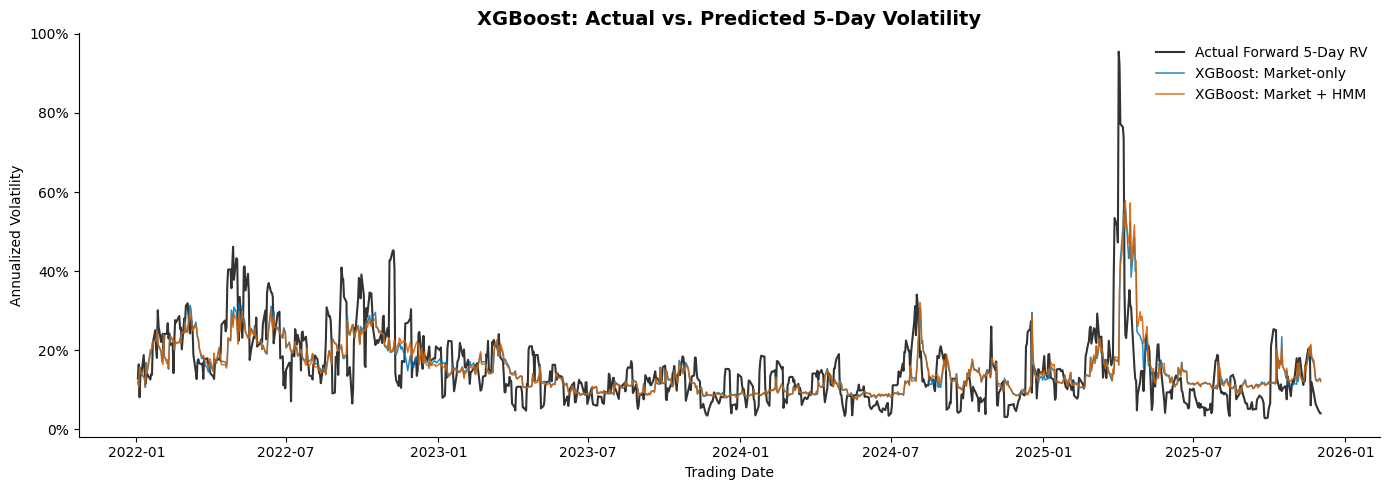

In [37]:
# Select primary 5-day test forecasts
xgb_plot = forecasts[
    (forecasts["Model"] == "XGBoost") &
    (forecasts["Horizon"] == 5) &
    (forecasts["Sample"] == "Test")
]

# Reshape predictions for comparison
xgb_wide = xgb_plot.pivot(
    index="Date",
    columns="Features",
    values="Predicted"
).sort_index()

# Actual forward volatility
actual_5d = test_df.set_index("Date")[
    "Forward_RV_5D"
].reindex(xgb_wide.index)

# Create and store figure
fig_xgb_5d_predictions, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    actual_5d.index,
    actual_5d,
    label="Actual Forward 5-Day RV",
    color="#333333",
    linewidth=1.5
)

ax.plot(
    xgb_wide.index,
    xgb_wide["Market-only"],
    label="XGBoost: Market-only",
    color="#0072B2",
    linewidth=1.1,
    alpha=0.85
)

ax.plot(
    xgb_wide.index,
    xgb_wide["Market + HMM"],
    label="XGBoost: Market + HMM",
    color="#D55E00",
    linewidth=1.1,
    alpha=0.85
)

ax.set_title(
    "XGBoost: Actual vs. Predicted 5-Day Volatility",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Trading Date")
ax.set_ylabel("Annualized Volatility")

ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(xmax=1.0)
)

ax.legend(frameon=False)
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_xgb_5d_predictions.tight_layout()
plt.show()

Visualization - Incremental Test RMSE Improvement from HMM Information

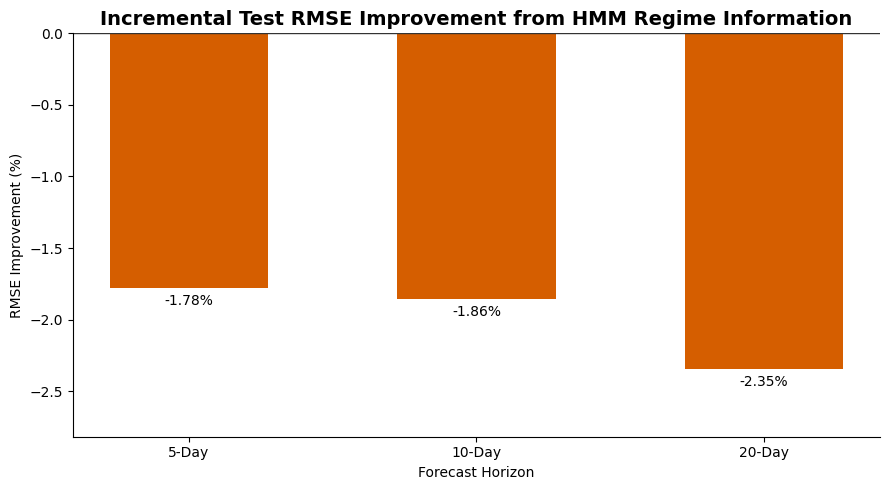

In [38]:
# Incremental test RMSE improvement from HMM probabilities
xgb_hmm_test_improvement = (
    1 - xgb_rmse_test["Market + HMM"] /
    xgb_rmse_test["Market-only"]
) * 100

# Create and store figure
fig_xgb_hmm_test_improvement, ax = plt.subplots(
    figsize=(9, 5)
)

bar_colors = [
    "#0072B2" if value >= 0 else "#D55E00"
    for value in xgb_hmm_test_improvement
]

bars = ax.bar(
    [f"{h}-Day" for h in xgb_hmm_test_improvement.index],
    xgb_hmm_test_improvement.values,
    color=bar_colors,
    width=0.55
)

ax.axhline(0, color="#333333", linewidth=1)

ax.bar_label(
    bars,
    fmt="%+.2f%%",
    padding=4
)

ax.set_title(
    "Incremental Test RMSE Improvement from HMM Regime Information",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("RMSE Improvement (%)")

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(y=0.2)

fig_xgb_hmm_test_improvement.tight_layout()
plt.show()


Visualization - XGBoost Feature Importance

Feature importance is examined for the regime-enhanced XGBoost model at the primary 5-day forecasting horizon to investigate the relative contribution of market characteristics and HMM regime probabilities.

Importance is measured using XGBoost's gain-based metric, which reflects the average reduction in the training objective achieved when a feature is used to split a decision tree.

The analysis examines whether regime probabilities contribute meaningfully to the fitted model relative to observable market predictors. Feature importance describes how the model uses its predictors but does not establish causal effects or independent improvements in out-of-sample forecasting accuracy.

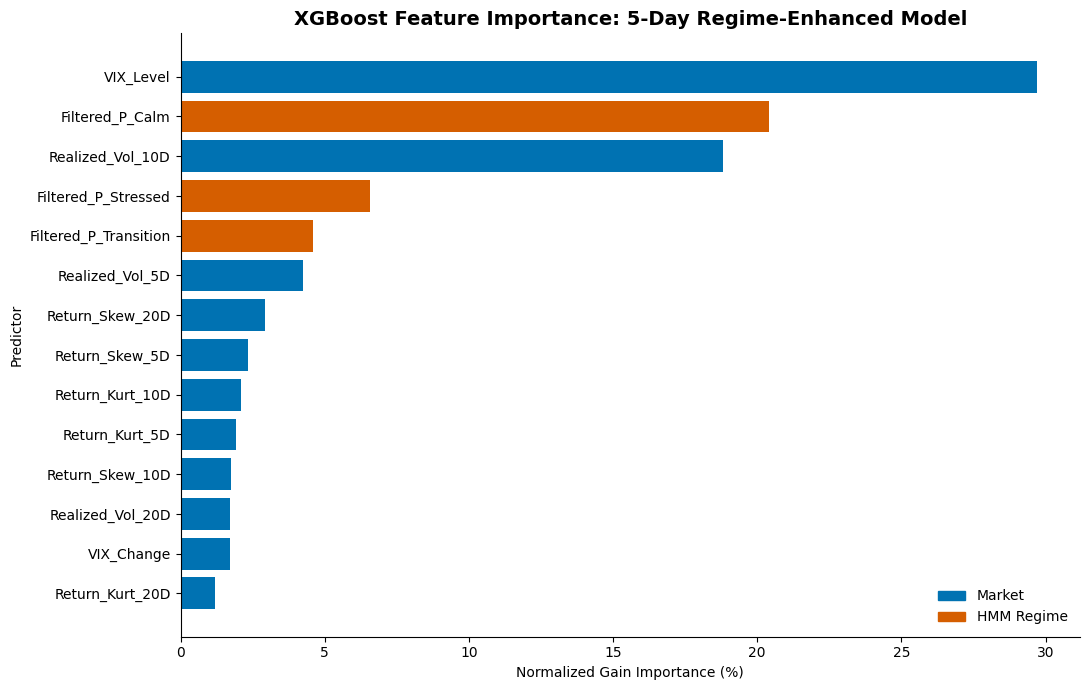

,Feature,Type,Importance (%)
0,VIX_Level,Market,29.71%
11,Filtered_P_Calm,HMM Regime,20.40%
3,Realized_Vol_10D,Market,18.83%
13,Filtered_P_Stressed,HMM Regime,6.56%
12,Filtered_P_Transition,HMM Regime,4.60%
2,Realized_Vol_5D,Market,4.23%
7,Return_Skew_20D,Market,2.92%
5,Return_Skew_5D,Market,2.34%
9,Return_Kurt_10D,Market,2.09%
8,Return_Kurt_5D,Market,1.93%


In [39]:

# Select fitted 5-day regime-enhanced XGBoost model
xgb_hmm_5d = xgb_models[(5, "Market + HMM")]

# Retrieve gain-based feature importance
booster = xgb_hmm_5d.get_booster()
gain_scores = booster.get_score(importance_type="gain")

# Build feature importance table
feature_importance = pd.DataFrame({
    "Feature": enhanced_features,
    "Gain": [
        gain_scores.get(feature, 0.0)
        for feature in enhanced_features
    ]
})

# Normalize importance for easier interpretation
total_gain = feature_importance["Gain"].sum()

feature_importance["Importance (%)"] = (
    feature_importance["Gain"] / total_gain * 100
)

feature_importance = feature_importance.sort_values(
    "Importance (%)",
    ascending=True
)

# Distinguish regime features from market predictors
feature_importance["Type"] = np.where(
    feature_importance["Feature"].isin(regime_predictors),
    "HMM Regime",
    "Market"
)

# Color palette
feature_colors = {
    "Market": "#0072B2",
    "HMM Regime": "#D55E00"
}

# Create and store figure
fig_xgb_feature_importance, ax = plt.subplots(
    figsize=(11, 7)
)

ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance (%)"],
    color=[
        feature_colors[t]
        for t in feature_importance["Type"]
    ]
)

ax.set_title(
    "XGBoost Feature Importance: 5-Day Regime-Enhanced Model",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Normalized Gain Importance (%)")
ax.set_ylabel("Predictor")

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(color="#0072B2", label="Market"),
        Patch(color="#D55E00", label="HMM Regime")
    ],
    frameon=False
)

fig_xgb_feature_importance.tight_layout()
plt.show()

# Display numerical results
display(
    feature_importance[
        ["Feature", "Type", "Importance (%)"]
    ].sort_values(
        "Importance (%)",
        ascending=False
    ).style.format({
        "Importance (%)": "{:.2f}%"
    })
)


### Observation : XGBoost Test Performance and Feature Importance

- **Primary Forecasting Performance:** The market-only XGBoost model achieved a test RMSE of 0.0756 and MAE of 0.0497 for the 5-day forecast, representing a 22.41% reduction in RMSE relative to the persistence baseline.

- **Comparison with Ridge Regression:** XGBoost outperformed persistence across all three forecasting horizons but achieved higher test RMSE than Ridge Regression. This suggests that the tested regularized linear specification generalized more effectively than the nonlinear XGBoost configurations.

- **Incremental HMM Contribution:** Incorporating HMM regime probabilities increased test RMSE by 1.78%, 1.86%, and 2.35% for the 5-, 10-, and 20-day forecasting horizons, respectively. The modest validation improvements observed at the 5- and 20-day horizons did not generalize to the independent test period.

- **Volatility Tracking:** Both XGBoost specifications captured broad movements in realized volatility but substantially underestimated extreme volatility spikes, particularly during the sharp market disruption observed in 2025.

- **Feature Importance:** VIX Level exhibited the highest normalized gain importance, followed by the Calm regime probability and 10-day historical realized volatility. Although the three HMM probabilities received substantial importance within the fitted model, their inclusion did not improve out-of-sample forecasting accuracy.

- **Modeling Implications:** The results indicate that feature importance within a nonlinear model does not necessarily translate into incremental predictive value. The HMM probabilities may contain information that overlaps with existing market predictors, limiting their additional forecasting contribution under the tested specifications.

### 12 Consolidated Out of Sample Model Performance

The out of sample forecasting performance of the persistence baseline, Ridge Regression, and XGBoost is consolidated to compare predictive accuracy across model specifications and forecasting horizons.

The comparison includes market-only and regime-enhanced specifications for Ridge Regression and XGBoost, alongside the persistence baseline. All models are evaluated using the same test observations from 2022–2025.

Performance is assessed using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE), with lower values indicating greater forecasting accuracy. The primary comparison focuses on 5-day forward realized volatility, while the 10- and 20-day horizons are examined as robustness checks.

This analysis establishes which supervised approach achieves the strongest forecasting performance and provides the foundation for assessing the incremental predictive contribution of HMM regime information.

### 12.1 Consolidate Test Results

In [40]:

# Select independent test-period results
final_results = results[
    results["Sample"] == "Test"
].copy()

# Define model order for presentation
model_order = {
    "Persistence": 0,
    "Ridge": 1,
    "XGBoost": 2
}

feature_order = {
    "Matched trailing volatility": 0,
    "Market-only": 1,
    "Market + HMM": 2
}

# Sort by horizon, model, and feature set
final_results["Model_Order"] = (
    final_results["Model"].map(model_order)
)

final_results["Feature_Order"] = (
    final_results["Features"].map(feature_order)
)

final_results = (
    final_results
    .sort_values([
        "Horizon",
        "Model_Order",
        "Feature_Order"
    ])
    .drop(columns=["Model_Order", "Feature_Order"])
    .reset_index(drop=True)
)

# Verify expected number of configurations
assert len(final_results) == 15, (
    "Expected 15 test configurations."
)

assert not final_results.duplicated(
    ["Model", "Features", "Horizon", "Sample"]
).any(), "Duplicate model results detected."

# Display consolidated results
display(
    final_results[
        ["Horizon", "Model", "Features", "RMSE", "MAE"]
    ].style.format({
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

,Horizon,Model,Features,RMSE,MAE
0,5,Persistence,Matched trailing volatility,0.0974,0.0647
1,5,Ridge,Market-only,0.0738,0.0492
2,5,Ridge,Market + HMM,0.0740,0.0494
3,5,XGBoost,Market-only,0.0756,0.0497
4,5,XGBoost,Market + HMM,0.0769,0.0504
5,10,Persistence,Matched trailing volatility,0.0849,0.0543
6,10,Ridge,Market-only,0.0670,0.0427
7,10,Ridge,Market + HMM,0.0673,0.0428
8,10,XGBoost,Market-only,0.0698,0.0427
9,10,XGBoost,Market + HMM,0.0711,0.0430


Visualization - Consolidate Test RMSE Preformance

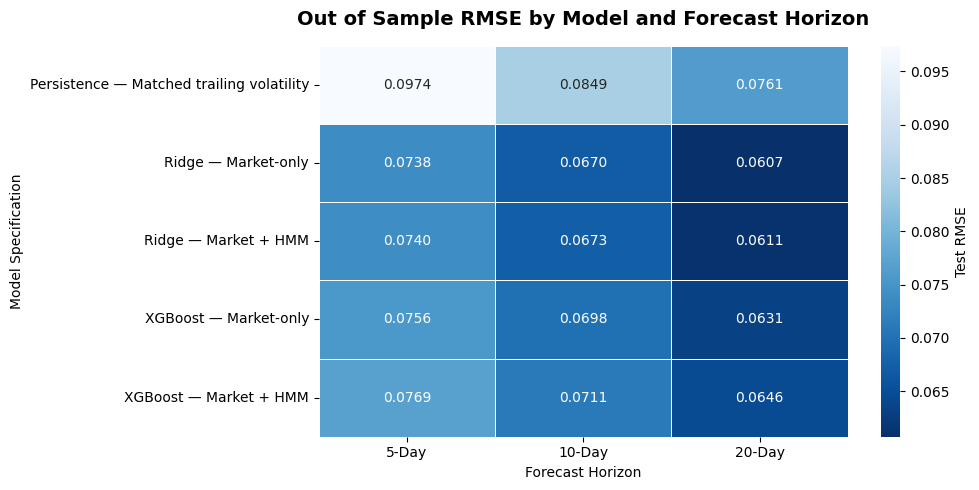

In [42]:

# Create descriptive model labels
final_results["Model Specification"] = (
    final_results["Model"] + " — " +
    final_results["Features"]
)

# Pivot test RMSE values
rmse_matrix = final_results.pivot(
    index="Model Specification",
    columns="Horizon",
    values="RMSE"
)

# Control display order
specification_order = [
    "Persistence — Matched trailing volatility",
    "Ridge — Market-only",
    "Ridge — Market + HMM",
    "XGBoost — Market-only",
    "XGBoost — Market + HMM"
]

rmse_matrix = rmse_matrix.reindex(
    index=specification_order,
    columns=list(HORIZONS)
)

# Create and store figure
fig_final_rmse_comparison, ax = plt.subplots(
    figsize=(10, 5)
)

sns.heatmap(
    rmse_matrix,
    cmap="Blues_r",
    annot=True,
    fmt=".4f",
    linewidths=0.5,
    cbar_kws={"label": "Test RMSE"},
    ax=ax
)

ax.set_title(
    "Out of Sample RMSE by Model and Forecast Horizon",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Model Specification")

ax.set_xticklabels(["5-Day", "10-Day", "20-Day"])
ax.tick_params(axis="y", rotation=0)

fig_final_rmse_comparison.tight_layout()
plt.show()


### 12.2 Relative Forecasting Imrpovement Over Persistence
The forecasting performance of Ridge Regression and XGBoost is compared against the persistence baseline to quantify the additional predictive value of supervised learning.

For each forecasting horizon, the percentage reduction in RMSE relative to persistence is calculated. Positive improvements indicate lower forecasting errors than the baseline, while negative values indicate weaker performance.

The comparison is conducted using identical test observations within each forecasting horizon, allowing the relative benefits of different model specifications to be assessed consistently.

In [43]:

# Extract persistence RMSE by horizon
persistence_rmse = (
    final_results[
        final_results["Model"] == "Persistence"
    ]
    .set_index("Horizon")["RMSE"]
)

# Select supervised models
supervised_results = final_results[
    final_results["Model"].isin(["Ridge", "XGBoost"])
].copy()

# Calculate improvement over persistence
supervised_results["RMSE_Improvement_%"] = (
    1 - supervised_results["RMSE"] /
    supervised_results["Horizon"].map(persistence_rmse)
) * 100

# Create comparison table
rmse_improvement_table = supervised_results.pivot(
    index=["Model", "Features"],
    columns="Horizon",
    values="RMSE_Improvement_%"
)

rmse_improvement_table = rmse_improvement_table.reindex(
    columns=list(HORIZONS)
)

display(
    rmse_improvement_table.style.format("{:+.2f}%")
)

Visualization - Improvement Over Persistence

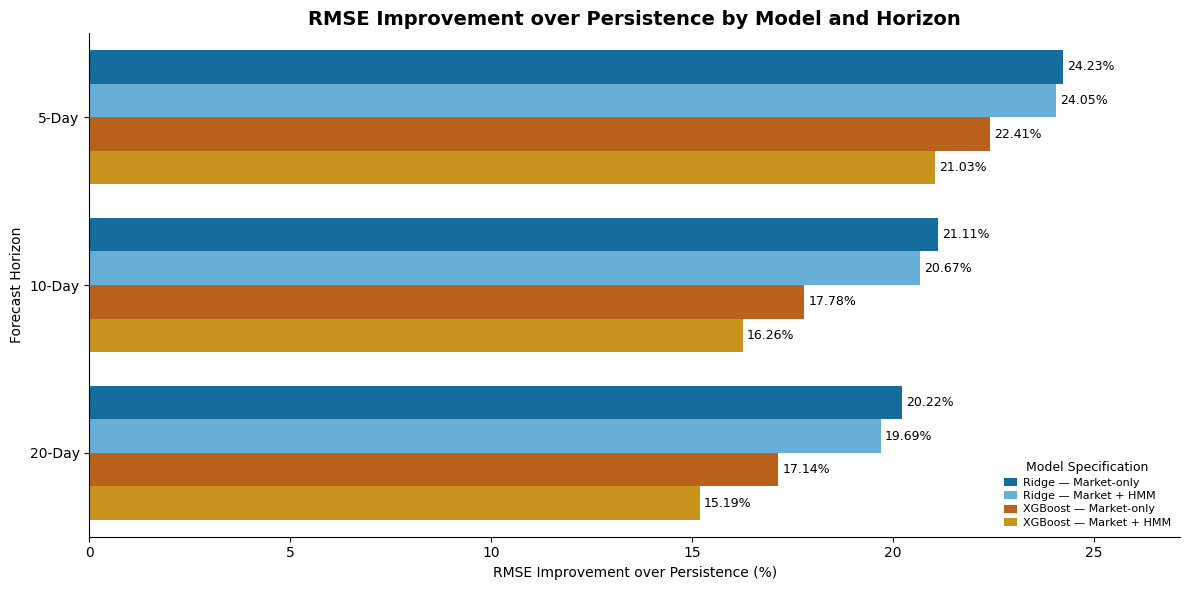

In [58]:

# Create descriptive labels
plot_df = supervised_results.copy()

plot_df["Specification"] = (
    plot_df["Model"] + " — " + plot_df["Features"]
)

# Consistent color-blind-friendly palette
model_palette = {
    "Ridge — Market-only": "#0072B2",
    "Ridge — Market + HMM": "#56B4E9",
    "XGBoost — Market-only": "#D55E00",
    "XGBoost — Market + HMM": "#E69F00"
}

# Create and store figure
fig_relative_rmse_improvement, ax = plt.subplots(
    figsize=(12, 6)
)

sns.barplot(
    data=plot_df,
    y="Horizon",
    x="RMSE_Improvement_%",
    hue="Specification",
    hue_order=list(model_palette),
    palette=model_palette,
    orient="h",
    native_scale=False,
    errorbar=None,
    ax=ax
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        label_type="edge",
        padding=3,
        fontsize=9
    )

# Allow space for percentage labels
ax.set_xlim(
    0,
    plot_df["RMSE_Improvement_%"].max() * 1.12
)

ax.set_title(
    "RMSE Improvement over Persistence by Model and Horizon",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("RMSE Improvement over Persistence (%)")
ax.set_ylabel("Forecast Horizon")

ax.set_yticklabels(["5-Day", "10-Day", "20-Day"])

ax.legend(
    title="Model Specification",
    loc="lower right",
    fontsize=8,
    title_fontsize=9,
    frameon=False,
    handlelength=1.2,
    handleheight=0.7,
    handletextpad=0.5,
    labelspacing=0.3,
    borderpad=0.3,
    ncol=1
)

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_relative_rmse_improvement.tight_layout()
plt.show()


### 12.3 Incremental Contribution of HMM Regime Information

The incremental predictive contribution of the HMM regime probabilities is evaluated by comparing the market-only and regime-enhanced specifications of Ridge Regression and XGBoost.

For each model and forecasting horizon, the percentage change in RMSE resulting from the inclusion of HMM probabilities is calculated using the independent test dataset. Positive values indicate an improvement in forecasting accuracy, while negative values indicate a deterioration relative to the market-only specification.

This comparison isolates the observed performance difference associated with incorporating regime information under each modeling approach. The primary analysis focuses on the 5-day forecasting horizon, with 10- and 20-day results used to assess whether the findings remain consistent across longer horizons.

In [59]:

# Select supervised model results
hmm_results = final_results[
    final_results["Model"].isin(["Ridge", "XGBoost"])
].copy()

# Compare market-only vs. regime-enhanced RMSE
hmm_comparison = hmm_results.pivot(
    index=["Model", "Horizon"],
    columns="Features",
    values="RMSE"
).reset_index()

# Calculate incremental RMSE improvement
hmm_comparison["HMM_Improvement_%"] = (
    1 - hmm_comparison["Market + HMM"] /
    hmm_comparison["Market-only"]
) * 100

# Rename columns for presentation
hmm_comparison = hmm_comparison.rename(columns={
    "Market-only": "Market_Only_RMSE",
    "Market + HMM": "Market_HMM_RMSE"
})

# Sort results
hmm_comparison = hmm_comparison.sort_values(
    ["Horizon", "Model"]
).reset_index(drop=True)

display(
    hmm_comparison.style.format({
        "Market_Only_RMSE": "{:.4f}",
        "Market_HMM_RMSE": "{:.4f}",
        "HMM_Improvement_%": "{:+.2f}%"
    })
)


Features,Model,Horizon,Market_HMM_RMSE,Market_Only_RMSE,HMM_Improvement_%
0,Ridge,5,0.0740,0.0738,-0.24%
1,XGBoost,5,0.0769,0.0756,-1.78%
2,Ridge,10,0.0673,0.0670,-0.56%
3,XGBoost,10,0.0711,0.0698,-1.86%
4,Ridge,20,0.0611,0.0607,-0.66%
5,XGBoost,20,0.0646,0.0631,-2.35%


Visualization - Incremental HMM Improvement Across Models

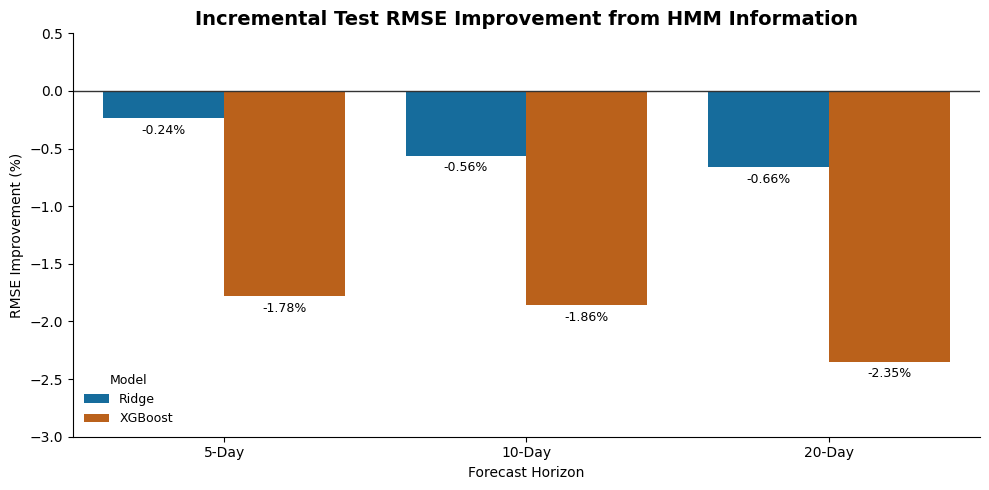

In [61]:

# Prepare comparison data
plot_hmm = hmm_comparison.copy()

# Consistent model colors
hmm_palette = {
    "Ridge": "#0072B2",
    "XGBoost": "#D55E00"
}

# Create and store figure
fig_final_hmm_improvement, ax = plt.subplots(
    figsize=(10, 5)
)

sns.barplot(
    data=plot_hmm,
    x="Horizon",
    y="HMM_Improvement_%",
    hue="Model",
    order=list(HORIZONS),
    hue_order=["Ridge", "XGBoost"],
    palette=hmm_palette,
    errorbar=None,
    ax=ax
)

# Add percentage labels to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%+.2f%%",
        label_type="edge",
        padding=4,
        fontsize=9
    )

# Reference line at zero
ax.axhline(0, color="#333333", linewidth=1)

ax.set_title(
    "Incremental Test RMSE Improvement from HMM Information",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("RMSE Improvement (%)")
ax.set_xticklabels(["5-Day", "10-Day", "20-Day"])

# Leave room for negative labels
ax.set_ylim(
    min(-3, plot_hmm["HMM_Improvement_%"].min() * 1.25),
    0.5
)

# Compact legend
ax.legend(
    title="Model",
    fontsize=9,
    title_fontsize=9,
    frameon=False,
    loc="lower left"
)

ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)

fig_final_hmm_improvement.tight_layout()
plt.show()


### Observation : Incremental Contribution

1. HMM information consistently reduces forecasting accuracy. All six comparisons produce negative improvements, indicating that the addition of regime probabilities increases test RMSE relative to the corresponding market-only model.
2. The deterioration is larger for XGBoost. At the primary 5-day horizon, HMM information increases XGBoost RMSE by approximately 1.78%, compared with just 0.24% for Ridge. This suggests that the tested nonlinear model does not extract additional generalizable predictive value from the regime probabilities.
3. The deterioration increases slightly with the forecasting horizon. Both models exhibit progressively larger negative improvements from 5 to 20 days, although these small differences are insufficient to establish a statistically meaningful horizon effect.
The results are consistent with our earlier finding that the HMM probabilities are strongly related to existing market characteristics, particularly VIX and historical realized volatility. They may therefore provide limited additional information once those predictors are already included.
Importantly, this does not invalidate Model B's regime classifications. It indicates that the inferred regimes did not provide incremental forecasting improvements under the supervised specifications tested.

### 12.4 Statistical Comparison of Forecast Accuracy

A Diebold–Mariano-style forecast comparison test is conducted to determine whether differences in out-of-sample forecasting accuracy are statistically significant.

The test compares the squared forecasting errors of two competing models over the independent 2022–2025 test period. A Newey–West heteroskedasticity-and-autocorrelation-consistent (HAC) variance estimate is applied to account for potential serial dependence arising from overlapping forward volatility windows.

For each trading date, the difference in squared forecasting errors is calculated as:

**Loss Difference = (Error of Model A)² − (Error of Model B)²**

Where:

- **Error of Model A:** Actual volatility minus Model A's predicted volatility.
- **Error of Model B:** Actual volatility minus Model B's predicted volatility.
- **Loss Difference:** Difference between the two models' squared forecasting errors for the same trading date.

The resulting values are interpreted as follows:

- **Positive average loss difference:** Model B produces lower average squared forecasting errors.
- **Negative average loss difference:** Model A produces lower average squared forecasting errors.
- **Average loss difference equal to zero:** The models have equal average squared forecasting loss.

The **null hypothesis (H₀)** states that the expected loss difference between the two models is zero, indicating equal expected forecasting accuracy.

The test statistic is calculated as:

**Test Statistic = Average Loss Difference / HAC-Adjusted Standard Error**

Statistical significance is evaluated using a two-sided normal approximation at the 5% significance level (p-value < 0.05).

A statistically significant result provides evidence that the models differ in expected squared forecasting loss, while a non-significant result indicates insufficient evidence to reject equal expected forecasting loss.

The analysis compares Ridge Regression against persistence and evaluates whether incorporating HMM regime probabilities improves Ridge Regression and XGBoost across the 5-, 10-, and 20-day forecasting horizons.


In [63]:
# Diebold-Mariano-style test using HAC standard errors
def dm_hac_test(forecast_a, forecast_b, horizon):

    # Align forecasts on trading dates
    paired = pd.concat(
        [
            forecast_a.set_index("Date")[
                ["Actual", "Predicted"]
            ].rename(columns={
                "Actual": "Actual_A",
                "Predicted": "Pred_A"
            }),
            forecast_b.set_index("Date")[
                ["Actual", "Predicted"]
            ].rename(columns={
                "Actual": "Actual_B",
                "Predicted": "Pred_B"
            })
        ],
        axis=1,
        join="inner"
    ).dropna()

    assert paired.index.is_unique
    assert len(paired) > horizon

    assert np.allclose(
        paired["Actual_A"],
        paired["Actual_B"]
    ), "Forecast targets do not match."

    # Squared forecasting errors
    error_a = paired["Actual_A"] - paired["Pred_A"]
    error_b = paired["Actual_B"] - paired["Pred_B"]

    # Positive means Model B has lower squared loss
    loss_diff = error_a**2 - error_b**2

    # Estimate mean loss difference with HAC covariance
    X = np.ones((len(loss_diff), 1))

    fitted = sm.OLS(
        loss_diff.to_numpy(),
        X
    ).fit(
        cov_type="HAC",
        cov_kwds={
            "maxlags": horizon - 1,
            "use_correction": True
        },
        use_t=False
    )

    return {
        "Observations": len(paired),
        "Mean_Loss_Diff": float(fitted.params[0]),
        "DM_Statistic": float(fitted.tvalues[0]),
        "P_Value": float(fitted.pvalues[0])
    }


In [64]:

# Define model comparisons
dm_comparisons = [
    (
        "Ridge vs Persistence",
        ("Persistence", "Matched trailing volatility"),
        ("Ridge", "Market-only")
    ),
    (
        "HMM Contribution: Ridge",
        ("Ridge", "Market-only"),
        ("Ridge", "Market + HMM")
    ),
    (
        "HMM Contribution: XGBoost",
        ("XGBoost", "Market-only"),
        ("XGBoost", "Market + HMM")
    )
]

dm_records = []

for h in HORIZONS:

    for comparison_name, model_a, model_b in dm_comparisons:

        # Select paired test forecasts
        forecast_a = forecasts[
            (forecasts["Model"] == model_a[0]) &
            (forecasts["Features"] == model_a[1]) &
            (forecasts["Horizon"] == h) &
            (forecasts["Sample"] == "Test")
        ]

        forecast_b = forecasts[
            (forecasts["Model"] == model_b[0]) &
            (forecasts["Features"] == model_b[1]) &
            (forecasts["Horizon"] == h) &
            (forecasts["Sample"] == "Test")
        ]

        test_result = dm_hac_test(
            forecast_a,
            forecast_b,
            horizon=h
        )

        dm_records.append({
            "Horizon": h,
            "Comparison": comparison_name,
            **test_result
        })

# Consolidate results
dm_results = pd.DataFrame(dm_records)

# Add statistical significance classification
dm_results["Significant_5pct"] = (
    dm_results["P_Value"] < 0.05
)

display(
    dm_results.style.format({
        "Mean_Loss_Diff": "{:+.6f}",
        "DM_Statistic": "{:+.3f}",
        "P_Value": "{:.4f}"
    })
)


,Horizon,Comparison,Observations,Mean_Loss_Diff,DM_Statistic,P_Value,Significant_5pct
0,5,Ridge vs Persistence,983,+0.004041,+3.233,0.0012,True
1,5,HMM Contribution: Ridge,983,-0.000026,-0.654,0.5133,False
2,5,HMM Contribution: XGBoost,983,-0.000205,-1.742,0.0815,False
3,10,Ridge vs Persistence,983,+0.002720,+2.088,0.0368,True
4,10,HMM Contribution: Ridge,983,-0.000050,-1.186,0.2357,False
5,10,HMM Contribution: XGBoost,983,-0.000183,-1.259,0.2079,False
6,20,Ridge vs Persistence,983,+0.002106,+1.568,0.1169,False
7,20,HMM Contribution: Ridge,983,-0.000049,-1.111,0.2667,False
8,20,HMM Contribution: XGBoost,983,-0.000189,-1.507,0.1318,False


Visualization - Forecast Preformance  

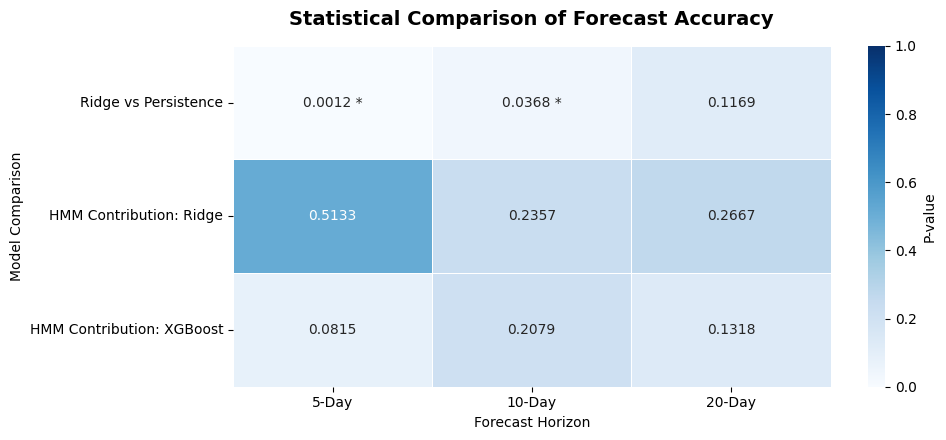

In [65]:

# Create p-value matrix
pvalue_matrix = dm_results.pivot(
    index="Comparison",
    columns="Horizon",
    values="P_Value"
)

pvalue_matrix = pvalue_matrix.reindex(
    index=[
        "Ridge vs Persistence",
        "HMM Contribution: Ridge",
        "HMM Contribution: XGBoost"
    ],
    columns=list(HORIZONS)
)

# Create readable cell annotations
pvalue_labels = pvalue_matrix.map(
    lambda p: f"{p:.4f}" + (" *" if p < 0.05 else "")
)

# Create and store figure
fig_dm_significance, ax = plt.subplots(
    figsize=(10, 4.5)
)

sns.heatmap(
    pvalue_matrix,
    annot=pvalue_labels,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "P-value"},
    ax=ax
)

ax.set_title(
    "Statistical Comparison of Forecast Accuracy",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Model Comparison")
ax.set_xticklabels(["5-Day", "10-Day", "20-Day"])
ax.tick_params(axis="y", rotation=0)

fig_dm_significance.tight_layout()
plt.show()


### Observation : Forecast Preformance
1. Ridge Regression significantly outperforms persistence at shorter horizons.
The 5-day forecast produces a p-value of 0.0012, providing strong evidence that market-only Ridge Regression achieves lower expected squared forecasting loss than persistence.
The 10-day comparison is also significant at the unadjusted 5% level (p = 0.0368). However, the 20-day result is not statistically significant (p = 0.1169).
2. HMM regime information does not produce statistically significant improvements.
None of the six HMM comparisons produces a p-value below 0.05. Although adding regime probabilities increases test RMSE in both models, the statistical tests do not establish that these differences are distinguishable from zero.
3. The primary 5-day result is the strongest finding.
After applying a Bonferroni correction across all nine comparisons, the 5-day Ridge-versus-persistence result remains significant, whereas the 10-day result does not. This provides stronger support for our primary forecasting objective than for the longer-horizon robustness checks.



### Observation : Final Model Comparison

- **Primary Forecasting Performance:** Market-only Ridge Regression achieved the lowest test RMSE (0.0738) and MAE (0.0490) for the primary 5-day forecasting horizon, reducing RMSE by approximately 24.3% relative to persistence.

- **Supervised Model Comparison:** Both Ridge Regression and XGBoost outperformed the persistence baseline across all three forecasting horizons. However, Ridge consistently achieved lower test RMSE, suggesting that the regularized linear specification generalized more effectively than the tested nonlinear configurations.

- **Incremental HMM Contribution:** Incorporating HMM regime probabilities increased test RMSE across both supervised models and all three horizons. The deterioration ranged from 0.24% to 0.66% for Ridge and 1.78% to 2.35% for XGBoost, indicating that regime information did not provide incremental forecasting improvements under the tested specifications.

- **Statistical Significance:** HAC-adjusted forecast comparisons identified statistically significant improvements for Ridge over persistence at the 5-day (p = 0.0012) and 10-day (p = 0.0368) horizons at the unadjusted 5% level. Only the primary 5-day improvement remained significant after a Bonferroni correction across nine comparisons.

- **HMM Statistical Contribution:** None of the six HMM comparisons produced statistically significant differences in expected squared forecasting loss at the 5% level. Consequently, the observed deterioration from incorporating regime probabilities cannot be interpreted as conclusive evidence that HMM information reduces forecasting accuracy.

- **Modeling Implications:** The findings demonstrate that engineered market characteristics provide useful predictive information beyond volatility persistence. However, the inferred market regimes do not demonstrate additional out-of-sample forecasting value under the tested Ridge and XGBoost specifications. This distinction highlights the difference between identifying meaningful market regimes and establishing their incremental predictive utility.

## 13. Model A : Conslusions and Limitations

### 13.1 Key Findings

Model A evaluated whether incorporating market regime information generated by Model B improves forward realized volatility forecasting. The primary analysis focused on a 5-day forecasting horizon, while 10- and 20-day forecasts served as robustness checks.

Three forecasting approaches were evaluated: a persistence baseline, Ridge Regression, and XGBoost. The supervised models were estimated using market-only predictors and regime-enhanced specifications incorporating filtered HMM probabilities.

The main findings are summarized below:

- **Forecasting Performance:** Both Ridge Regression and XGBoost outperformed the persistence baseline across all three horizons. Market-only Ridge Regression achieved the lowest test RMSE, with a 24.3% improvement over persistence at the primary 5-day horizon.

- **Nonlinear Modeling:** XGBoost achieved lower validation RMSE than Ridge Regression, but this advantage did not generalize to the independent test period. The tested regularized linear model consistently achieved better out-of-sample forecasting accuracy.

- **Incremental Regime Information:** Adding HMM regime probabilities did not improve test RMSE for either supervised model across the three horizons. The deterioration was relatively small for Ridge Regression and more pronounced for XGBoost.

- **Statistical Evidence:** HAC-adjusted forecast comparisons indicated that market-only Ridge Regression significantly outperformed persistence at the primary 5-day horizon (p = 0.0012). However, no statistically significant incremental forecasting benefit was identified from incorporating HMM probabilities.

Overall, the findings demonstrate that engineered market characteristics provide useful information for forecasting future volatility, while inferred market regime probabilities do not offer additional predictive improvements under the tested specifications.

### 13.2 Methodological Limitations

Several limitations should be considered when interpreting the results:

- **Historical Evaluation Period:** The analysis uses historical S&P 500 and VIX observations through 2025. Forecasting performance may vary under future market conditions or structural changes not represented in the sample.

- **Regime Information Redundancy:** The HMM regime probabilities are derived from market characteristics that overlap with the supervised predictors, particularly VIX and historical realized volatility. This may limit their incremental predictive contribution.

- **Model Specifications:** Ridge Regression and XGBoost were evaluated using predefined feature sets and limited hyperparameter searches. Alternative specifications, feature interactions, or forecasting approaches may produce different results.

- **Overlapping Forecast Windows:** Forward realized volatility targets use overlapping trading-day windows, creating serial dependence among forecasting errors. Although boundary purges and HAC-adjusted statistical tests were applied, the resulting inference remains sensitive to the chosen variance-estimation assumptions.

- **Statistical Interpretation:** The absence of statistically significant improvements from HMM probabilities does not establish that regime information has no predictive value under all market conditions or alternative model specifications.

These limitations suggest that the findings should be interpreted as evidence regarding the specific models, features, and historical evaluation periods examined rather than universal conclusions about volatility forecasting.

### 13.3 Implications for the Overall Project

The overall project combines unsupervised market regime identification with supervised volatility forecasting to investigate whether inferred market states provide additional predictive information beyond observable market characteristics.

Model B identified three interpretable market regimes—Calm, Transition, and Stressed—using a Gaussian Hidden Markov Model. These regimes provide a structured description of historical market conditions, including differences in volatility levels and regime persistence.

Model A extended this analysis by incorporating the filtered HMM regime probabilities into Ridge Regression and XGBoost forecasting models.

Although the regime probabilities were associated with future realized volatility and received substantial feature importance within XGBoost, their inclusion did not improve out-of-sample forecasting accuracy. This highlights an important distinction between identifying meaningful patterns in market data and demonstrating their incremental predictive value.

The results suggest that the regime information may summarize characteristics already captured by VIX and historical realized volatility. Nevertheless, the unsupervised approach remains useful for characterizing market conditions and examining how volatility dynamics differ across inferred states.

The project therefore demonstrates both the potential and limitations of combining unsupervised learning with supervised forecasting. **Market regime identification provides an interpretable representation of market behavior, but its predictive contribution must be independently validated rather than assumed.**

--------------------------------------------------------------------------------

## Misc

### Save Visuals

In [66]:
from pathlib import Path

In [67]:
# Create output directory
output_dir = Path("Model_A_Visualizations")
output_dir.mkdir(parents=True, exist_ok=True)

# Figure names and notebook variables
figure_registry = {
    # Section 6: Forecasting targets
    "6_3_Forward_RV_TimeSeries": "fig_forward_rv_timeseries",
    "6_4_Forward_RV_Distribution": "fig_forward_rv_distribution",
    "6_4_Forward_RV_Boxplot": "fig_forward_rv_boxplot",

    # Section 7: Predictor diagnostics
    "7_3_Predictor_Correlation": "fig_predictor_corr",
    "7_3_Predictor_Target_Correlation": "fig_predictor_target_corr",

    # Section 8: Chronological splitting
    "8_3_Chronological_Split": "fig_chronological_split",

    # Section 9: Persistence baseline
    "9_4_Persistence_5D": "fig_persistence_5d",
    "9_4_Persistence_Errors": "fig_persistence_errors",

    # Section 10: Ridge regression
    "10_3_Ridge_Tuning": "fig_ridge_tuning",
    "10_6_Ridge_5D_Predictions": "fig_ridge_5d_predictions",
    "10_6_Ridge_HMM_Improvement": "fig_ridge_hmm_improvement",

    # Section 11: XGBoost
    "11_4_XGBoost_Tuning": "fig_xgb_tuning",
    "11_4_XGBoost_HMM_Validation": "fig_xgb_hmm_improvement",
    "11_5_XGBoost_5D_Predictions": "fig_xgb_5d_predictions",
    "11_5_XGBoost_HMM_Test": "fig_xgb_hmm_test_improvement",
    "11_6_XGBoost_Feature_Importance": "fig_xgb_feature_importance",

    # Section 12: Final comparison
    "12_1_Final_RMSE_Comparison": "fig_final_rmse_comparison",
    "12_2_Improvement_Over_Persistence": "fig_relative_rmse_improvement",
    "12_3_Final_HMM_Improvement": "fig_final_hmm_improvement",
    "12_4_DM_Significance": "fig_dm_significance"
}

# Export figures individually
saved_files = []
missing_figures = []

for filename, variable_name in figure_registry.items():

    fig = globals().get(variable_name)

    if isinstance(fig, plt.Figure):
        filepath = output_dir / f"{filename}.png"

        fig.savefig(
            filepath,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        saved_files.append(filepath)

    else:
        missing_figures.append(variable_name)

print(f"Figures saved: {len(saved_files)}")
print(f"Figures unavailable: {len(missing_figures)}")
print(f"Output directory: {output_dir.resolve()}")

if missing_figures:
    print("\nFigures to regenerate:")
    for name in missing_figures:
        print("-", name)


Figures saved: 18
Figures unavailable: 2
Output directory: /content/Model_A_Visualizations

Figures to regenerate:
- fig_persistence_5d
- fig_persistence_errors
